# Notebook 07: Comprehensive APTOS-Only Evaluation
## 2-Phase Single Model vs K-Fold Ensemble — EfficientNet-B3

**Purpose:** Head-to-head comparison of the 2-phase trained single model against
the 5-fold ensemble (trained on multi-source data), evaluated exclusively on
the APTOS 2019 test split (531 images).

**Comparison Framework:**
| Level | Description |
|-------|-------------|
| A0 | 2-Phase Single Model (APTOS-trained, simple head) |
| A | Individual fold models (Fold 1–5, multi-source trained) |
| B | 5-Fold Soft Ensemble (no TTA) |
| C | 5-Fold Ensemble + 8× TTA |
| D | 5-Fold Ensemble + TTA + Optimized Threshold |

**Test Set:** APTOS 2019 only (`splits_aptos/test_split.csv`, 531 images)

| Section | Content |
|---------|---------|
| 1–2 | Imports, configuration, model & test set loading |
| 3 | Test set inference (all levels) |
| 4 | Core metrics + bootstrap 95% CIs |
| 5 | ROC curve with clinical operating points |
| 6 | Precision–Recall curve |
| 7 | Confusion matrices (optimal & clinical thresholds) |
| 8 | Threshold sensitivity analysis |
| 9 | Calibration analysis |
| 10 | Subgroup analysis by DR grade |
| 11 | Error analysis (misclassified cases) |
| 12 | Summary dashboard & export |

---

## 1. Imports & Configuration

In [3]:
# ============================================================
# 1. Imports & Configuration
# ============================================================
import os, gc, json, warnings, random, copy, time
from pathlib import Path
from typing import Dict, List, Tuple

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, auc,
    accuracy_score, confusion_matrix, classification_report,
    cohen_kappa_score, matthews_corrcoef, f1_score,
    precision_score, recall_score, balanced_accuracy_score,
    log_loss, brier_score_loss,
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

# ── Reproducibility ──
SEED = 42
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
set_seed(SEED)

# ── Device ──
if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

# ── Paths ──
ROOT = Path(".")
SPLITS_DIR = ROOT / "splits_aptos"          # APTOS-only splits
KFOLD_DIR  = ROOT / "models" / "kfold"
TWOPHASE_CKPT = ROOT / "models" / "best_binary_model.pth"
EVAL_DIR   = ROOT / "evaluation" / "aptos_comprehensive"
FIG_DIR    = EVAL_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Config ──
CONFIG = {
    "model_name": "efficientnet_b3",
    "image_size": 384,
    "mean": [0.485, 0.456, 0.406],
    "std": [0.229, 0.224, 0.225],
    "n_folds": 5,
    "tta_times": 8,
    "batch_size": 16,
    "num_workers": 0,
    "pin_memory": False,
    "bootstrap_n": 2000,
}

# ── Plot style ──
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
PALETTE = {
    "no_dr": "#27ae60", "dr": "#c0392b", "blue": "#2980b9",
    "orange": "#e67e22", "purple": "#8e44ad", "gray": "#7f8c8d",
    "fold1": "#e74c3c", "fold2": "#3498db", "fold3": "#2ecc71",
    "fold4": "#9b59b6", "fold5": "#f39c12", "ensemble": "#1a1a2e",
    "twophase": "#16a085",  # Distinct color for 2-phase model
}

print(f"Device           : {DEVICE}")
print(f"Model            : {CONFIG['model_name']}")
print(f"Image size       : {CONFIG['image_size']}x{CONFIG['image_size']}")
print(f"K-Fold models    : {KFOLD_DIR}")
print(f"2-Phase model    : {TWOPHASE_CKPT}")
print(f"Test splits      : {SPLITS_DIR}")
print(f"Evaluation output: {EVAL_DIR}")
print(f"Bootstrap samples: {CONFIG['bootstrap_n']}")

Device           : mps
Model            : efficientnet_b3
Image size       : 384x384
K-Fold models    : models/kfold
2-Phase model    : models/best_binary_model.pth
Test splits      : splits_aptos
Evaluation output: evaluation/aptos_comprehensive
Bootstrap samples: 2000


## 2. Load Models & Test Set

In [5]:
# ============================================================
# 2a. Model architectures (TWO different architectures)
# ============================================================

# ── Architecture 1: K-Fold model (custom 3-layer head) ──
class DRBinaryModel(nn.Module):
    """K-Fold model: backbone + custom 3-layer head, output [B]"""
    def __init__(self, model_name='efficientnet_b3', pretrained=False):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        in_features = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(256, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features).squeeze(-1)  # Output: [B]


# ── Architecture 2: 2-Phase model (simple head via model.classifier) ──
def load_twophase_model(ckpt_path, model_name='efficientnet_b3', device='cpu'):
    """
    2-Phase model: timm model with replaced classifier.
    Head: Dropout(0.4) → Linear(1536, 1)
    Output: [B, 1] — needs .squeeze(-1) during inference
    Checkpoint key: 'model_state_dict'
    """
    model = timm.create_model(model_name, pretrained=False)
    n_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(n_features, 1),
    )
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model = model.to(device)
    model.eval()
    return model, ckpt


class DRDataset(Dataset):
    def __init__(self, df, transform, root=Path(".")):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.root = root

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(str(self.root / row["preprocessed_path"]))
        if img is None:
            raise FileNotFoundError(f"Cannot read: {self.root / row['preprocessed_path']}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.transform(image=img)["image"]
        label = torch.tensor(row["binary_label"], dtype=torch.float32)
        return img, label


# Transforms
val_transform = A.Compose([
    A.Resize(CONFIG["image_size"], CONFIG["image_size"]),
    A.Normalize(mean=CONFIG["mean"], std=CONFIG["std"]),
    ToTensorV2(),
])

tta_transform = A.Compose([
    A.Resize(CONFIG["image_size"], CONFIG["image_size"]),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=CONFIG["mean"], std=CONFIG["std"]),
    ToTensorV2(),
])

print("Model architectures & dataset class defined ✓")
print("  K-Fold model  : backbone + 3-layer head → squeeze(-1) → [B]")
print("  2-Phase model : timm classifier replaced → output [B,1] → squeeze(-1)")

Model architectures & dataset class defined ✓
  K-Fold model  : backbone + 3-layer head → squeeze(-1) → [B]
  2-Phase model : timm classifier replaced → output [B,1] → squeeze(-1)


In [6]:
# ============================================================
# 2b. Load APTOS-only test set
# ============================================================
df_test = pd.read_csv(SPLITS_DIR / "test_split.csv")
print(f"Test set: {len(df_test)} images (APTOS 2019 only)")
print(f"\nBinary distribution:")
print(df_test["binary_label"].value_counts().sort_index().to_string())
print(f"\nDR grade distribution:")
print(df_test["dr_grade"].value_counts().sort_index().to_string())

# Verify all files exist
missing = [p for p in df_test["preprocessed_path"] if not (ROOT / p).exists()]
assert len(missing) == 0, f"{len(missing)} files missing!"
print(f"\nAll {len(df_test)} files verified ✓")

Test set: 531 images (APTOS 2019 only)

Binary distribution:
binary_label
0    270
1    261

DR grade distribution:
dr_grade
0    270
1     58
2    144
3     22
4     37

All 531 files verified ✓


In [7]:
# ============================================================
# 2c. Load the 2-Phase single model
# ============================================================
assert TWOPHASE_CKPT.exists(), f"Missing: {TWOPHASE_CKPT}"
twophase_model, twophase_ckpt = load_twophase_model(
    TWOPHASE_CKPT, CONFIG["model_name"], DEVICE
)

# Print checkpoint info
print(f"2-Phase model loaded ✓")
print(f"  Checkpoint keys: {list(twophase_ckpt.keys())}")
if 'best_val_auc' in twophase_ckpt:
    print(f"  Best val AUC: {twophase_ckpt['best_val_auc']:.4f}")
if 'optimal_threshold' in twophase_ckpt:
    print(f"  Saved threshold: {twophase_ckpt['optimal_threshold']:.4f}")
tp_params = sum(p.numel() for p in twophase_model.parameters())
print(f"  Parameters: {tp_params:,}")

2-Phase model loaded ✓
  Checkpoint keys: ['model_name', 'num_features', 'dropout_rate', 'num_classes', 'image_size', 'mean', 'std', 'model_state_dict', 'best_val_auc', 'config']
  Best val AUC: 0.9958
  Parameters: 10,697,769


In [8]:
# ============================================================
# 2d. Load all 5 K-Fold models
# ============================================================
fold_models = []
for fold_idx in range(1, CONFIG["n_folds"] + 1):
    path = KFOLD_DIR / f"best_{CONFIG['model_name']}_fold{fold_idx}.pth"
    assert path.exists(), f"Missing: {path}"
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    model = DRBinaryModel(model_name=CONFIG["model_name"], pretrained=False)
    model.load_state_dict(ckpt["state_dict"])
    model = model.to(DEVICE)
    model.eval()
    fold_models.append(model)
    print(f"  Fold {fold_idx}: loaded (val AUC = {ckpt.get('best_val_auc', 'N/A'):.4f})")

print(f"\n✓ All {CONFIG['n_folds']} fold models loaded")
kf_params = sum(p.numel() for p in fold_models[0].parameters())
print(f"  Parameters per K-Fold model: {kf_params:,}")
print(f"\n  Total models loaded: 1 (2-phase) + {CONFIG['n_folds']} (K-Fold) = {CONFIG['n_folds']+1}")

  Fold 1: loaded (val AUC = 0.9997)
  Fold 2: loaded (val AUC = 0.9998)
  Fold 3: loaded (val AUC = 0.9988)
  Fold 4: loaded (val AUC = 0.9998)
  Fold 5: loaded (val AUC = 0.9994)

✓ All 5 fold models loaded
  Parameters per K-Fold model: 11,106,857

  Total models loaded: 1 (2-phase) + 5 (K-Fold) = 6


---
## 3. Test Set Inference — All Evaluation Levels

**Level A0:** 2-Phase single model (no TTA)  
**Level A:** Each fold predicts individually (no TTA)  
**Level B:** Average of 5-fold probabilities (soft voting, no TTA)  
**Level C:** 5-fold + 8× TTA per fold  
**Level D:** Level C + Youden's J optimized threshold

In [10]:
# ============================================================
# 3. Inference at all levels
# ============================================================
y_true = df_test["binary_label"].values.astype(int)

# ── Helper: basic inference for K-Fold model (output [B]) ──
@torch.no_grad()
def predict_kfold(model, df, transform):
    model.eval()
    ds = DRDataset(df, transform, ROOT)
    dl = DataLoader(ds, batch_size=CONFIG["batch_size"], shuffle=False,
                    num_workers=CONFIG["num_workers"], pin_memory=CONFIG["pin_memory"])
    all_logits = []
    for imgs, _ in dl:
        logits = model(imgs.to(DEVICE))  # [B]
        all_logits.append(logits.cpu())
    logits = torch.cat(all_logits).numpy()
    return 1 / (1 + np.exp(-logits))  # sigmoid


# ── Helper: basic inference for 2-Phase model (output [B,1]) ──
@torch.no_grad()
def predict_twophase(model, df, transform):
    model.eval()
    ds = DRDataset(df, transform, ROOT)
    dl = DataLoader(ds, batch_size=CONFIG["batch_size"], shuffle=False,
                    num_workers=CONFIG["num_workers"], pin_memory=CONFIG["pin_memory"])
    all_logits = []
    for imgs, _ in dl:
        logits = model(imgs.to(DEVICE)).squeeze(-1)  # [B,1] → [B]
        all_logits.append(logits.cpu())
    logits = torch.cat(all_logits).numpy()
    return 1 / (1 + np.exp(-logits))  # sigmoid


# ── Helper: TTA for K-Fold model ──
@torch.no_grad()
def predict_tta_kfold(model, df, n_tta=8):
    model.eval()
    all_probs = []
    for i in range(n_tta):
        tfm = val_transform if i == 0 else tta_transform
        ds = DRDataset(df, tfm, ROOT)
        dl = DataLoader(ds, batch_size=CONFIG["batch_size"], shuffle=False,
                        num_workers=CONFIG["num_workers"], pin_memory=CONFIG["pin_memory"])
        logits = []
        for imgs, _ in dl:
            logits.append(model(imgs.to(DEVICE)).cpu())
        logits = torch.cat(logits).numpy()
        all_probs.append(1 / (1 + np.exp(-logits)))
    return np.mean(all_probs, axis=0)


# ══════════════════════════════════════════════════════════════
# LEVEL A0: 2-Phase single model (no TTA)
# ══════════════════════════════════════════════════════════════
print("Level A0: 2-Phase single model inference...")
t0 = time.time()
twophase_probs = predict_twophase(twophase_model, df_test, val_transform)
print(f"  Done: {time.time()-t0:.1f}s")

# ══════════════════════════════════════════════════════════════
# LEVEL A: Individual fold predictions (no TTA)
# ══════════════════════════════════════════════════════════════
print("\nLevel A: Individual fold inference (no TTA)...")
fold_probs_noTTA = {}
for i, model in enumerate(fold_models):
    t0 = time.time()
    fold_probs_noTTA[f"Fold {i+1}"] = predict_kfold(model, df_test, val_transform)
    print(f"  Fold {i+1}: {time.time()-t0:.1f}s")

# ══════════════════════════════════════════════════════════════
# LEVEL B: 5-Fold Ensemble (no TTA)
# ══════════════════════════════════════════════════════════════
print("\nLevel B: 5-Fold Ensemble (no TTA)...")
ensemble_noTTA = np.mean(list(fold_probs_noTTA.values()), axis=0)

# ══════════════════════════════════════════════════════════════
# LEVEL C: 5-Fold Ensemble + TTA
# ══════════════════════════════════════════════════════════════
print("\nLevel C: 5-Fold Ensemble + 8x TTA...")
fold_probs_TTA = {}
for i, model in enumerate(fold_models):
    t0 = time.time()
    fold_probs_TTA[f"Fold {i+1}"] = predict_tta_kfold(model, df_test, CONFIG["tta_times"])
    print(f"  Fold {i+1}: {time.time()-t0:.1f}s")

ensemble_TTA = np.mean(list(fold_probs_TTA.values()), axis=0)

# ══════════════════════════════════════════════════════════════
# LEVEL D: Optimized threshold (on ensemble+TTA)
# ══════════════════════════════════════════════════════════════
print("\nLevel D: Threshold optimization (Youden's J)...")
fpr_opt, tpr_opt, thresholds_opt = roc_curve(y_true, ensemble_TTA)
J = tpr_opt - fpr_opt
opt_idx = np.argmax(J)
opt_threshold = thresholds_opt[opt_idx]
print(f"  Optimal threshold: {opt_threshold:.4f} (Youden's J = {J[opt_idx]:.4f})")

# ── Store all probabilities for comparison ──
all_predictions = {}

# 2-Phase single model
all_predictions["2-Phase Single"] = {"probs": twophase_probs, "threshold": 0.5}

# Individual folds
for name, probs in fold_probs_noTTA.items():
    all_predictions[name] = {"probs": probs, "threshold": 0.5}

# Ensembles
all_predictions["Ensemble (no TTA)"] = {"probs": ensemble_noTTA, "threshold": 0.5}
all_predictions["Ensemble + TTA"] = {"probs": ensemble_TTA, "threshold": 0.5}
all_predictions["Ensemble + TTA + OptThresh"] = {"probs": ensemble_TTA, "threshold": opt_threshold}

print(f"\n✓ All inference complete. {len(all_predictions)} evaluation levels ready.")

Level A0: 2-Phase single model inference...
  Done: 12.3s

Level A: Individual fold inference (no TTA)...
  Fold 1: 8.8s
  Fold 2: 7.6s
  Fold 3: 7.7s
  Fold 4: 7.6s
  Fold 5: 7.5s

Level B: 5-Fold Ensemble (no TTA)...

Level C: 5-Fold Ensemble + 8x TTA...
  Fold 1: 62.4s
  Fold 2: 62.7s
  Fold 3: 62.1s
  Fold 4: 63.0s
  Fold 5: 62.2s

Level D: Threshold optimization (Youden's J)...
  Optimal threshold: 0.3183 (Youden's J = 0.9814)

✓ All inference complete. 9 evaluation levels ready.


---
## 4. Core Metrics + Bootstrap 95% Confidence Intervals

In [12]:
# ============================================================
# 4. Comprehensive metrics for ALL evaluation levels
# ============================================================

def bootstrap_ci(y_true, y_score, metric_fn, n_boot=2000, ci=95, seed=42):
    rng = np.random.RandomState(seed)
    scores = []
    for _ in range(n_boot):
        idx = rng.choice(len(y_true), len(y_true), replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        try:
            scores.append(metric_fn(y_true[idx], y_score[idx]))
        except:
            continue
    alpha = (100 - ci) / 2
    return np.percentile(scores, alpha), np.percentile(scores, 100 - alpha)


def compute_full_metrics(y_true, probs, threshold=0.5, name="", do_bootstrap=False, n_boot=2000):
    """Compute comprehensive metrics at a given threshold."""
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()

    m = {
        "Model": name,
        "Threshold": threshold,
        "AUC-ROC": roc_auc_score(y_true, probs),
        "Accuracy": accuracy_score(y_true, preds),
        "Balanced Acc": balanced_accuracy_score(y_true, preds),
        "Sensitivity": tp / (tp + fn) if (tp + fn) > 0 else 0,
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "Precision": tp / (tp + fp) if (tp + fp) > 0 else 0,
        "NPV": tn / (tn + fn) if (tn + fn) > 0 else 0,
        "F1-Score": f1_score(y_true, preds, zero_division=0),
        "Cohen Kappa": cohen_kappa_score(y_true, preds),
        "MCC": matthews_corrcoef(y_true, preds),
        "Brier Score": brier_score_loss(y_true, probs),
        "Log Loss": log_loss(y_true, probs),
        "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn),
    }

    # AUC-PR
    prec_c, rec_c, _ = precision_recall_curve(y_true, probs)
    m["AUC-PR"] = auc(rec_c, prec_c)

    # Bootstrap CIs for key metrics
    if do_bootstrap:
        m["AUC-ROC CI"] = bootstrap_ci(y_true, probs, roc_auc_score, n_boot)
        _mk_acc = lambda yt, yp: accuracy_score(yt, (yp >= threshold).astype(int))
        _mk_sens = lambda yt, yp: recall_score(yt, (yp >= threshold).astype(int), zero_division=0)
        _mk_spec = lambda yt, yp: recall_score(yt, (yp >= threshold).astype(int), pos_label=0, zero_division=0)
        _mk_f1 = lambda yt, yp: f1_score(yt, (yp >= threshold).astype(int), zero_division=0)
        m["Accuracy CI"] = bootstrap_ci(y_true, probs, _mk_acc, n_boot)
        m["Sensitivity CI"] = bootstrap_ci(y_true, probs, _mk_sens, n_boot)
        m["Specificity CI"] = bootstrap_ci(y_true, probs, _mk_spec, n_boot)
        m["F1 CI"] = bootstrap_ci(y_true, probs, _mk_f1, n_boot)

    return m


# ── Compute metrics for all levels ──
N_BOOT = CONFIG["bootstrap_n"]
all_metrics = []

for name, pred_info in all_predictions.items():
    # Bootstrap for 2-Phase model and ensemble methods
    do_boot = ("Ensemble" in name) or ("2-Phase" in name)
    m = compute_full_metrics(y_true, pred_info["probs"], pred_info["threshold"],
                             name=name, do_bootstrap=do_boot, n_boot=N_BOOT)
    all_metrics.append(m)

# ── Comparison table ──
comp_cols = ["Model", "Threshold", "AUC-ROC", "AUC-PR", "Accuracy", "Sensitivity",
             "Specificity", "Precision", "F1-Score", "Cohen Kappa", "MCC", "Brier Score"]
df_comp = pd.DataFrame(all_metrics)[comp_cols]

print("=" * 110)
print("  COMPREHENSIVE COMPARISON — ALL EVALUATION LEVELS ON APTOS TEST SET (531 images)")
print("=" * 110)
print(df_comp.to_string(index=False, float_format="{:.4f}".format))
print("=" * 110)

# ── Bootstrap CIs ──
print("\n  Bootstrap 95% Confidence Intervals:")
for m in all_metrics:
    if "AUC-ROC CI" in m:
        print(f"\n  {m['Model']}:")
        for metric_name in ["AUC-ROC", "Accuracy", "Sensitivity", "Specificity", "F1"]:
            ci_key = f"{metric_name} CI"
            if ci_key in m:
                lo, hi = m[ci_key]
                val = m.get(metric_name, m.get(f"{metric_name}-Score", 0))
                print(f"    {metric_name:<20s}: {val:.4f} [{lo:.4f}, {hi:.4f}]")

  COMPREHENSIVE COMPARISON — ALL EVALUATION LEVELS ON APTOS TEST SET (531 images)
                     Model  Threshold  AUC-ROC  AUC-PR  Accuracy  Sensitivity  Specificity  Precision  F1-Score  Cohen Kappa    MCC  Brier Score
            2-Phase Single     0.5000   0.9992  0.9992    0.9887       0.9885       0.9889     0.9885    0.9885       0.9774 0.9774       0.0093
                    Fold 1     0.5000   0.9973  0.9978    0.9906       0.9885       0.9926     0.9923    0.9904       0.9812 0.9812       0.0097
                    Fold 2     0.5000   0.9957  0.9946    0.9849       0.9808       0.9889     0.9884    0.9846       0.9699 0.9699       0.0137
                    Fold 3     0.5000   0.9994  0.9993    0.9812       0.9655       0.9963     0.9960    0.9805       0.9623 0.9627       0.0130
                    Fold 4     0.5000   0.9988  0.9988    0.9831       0.9885       0.9778     0.9773    0.9829       0.9661 0.9662       0.0135
                    Fold 5     0.5000   0.9972  

---
## 5. ROC Curve with Clinical Operating Points

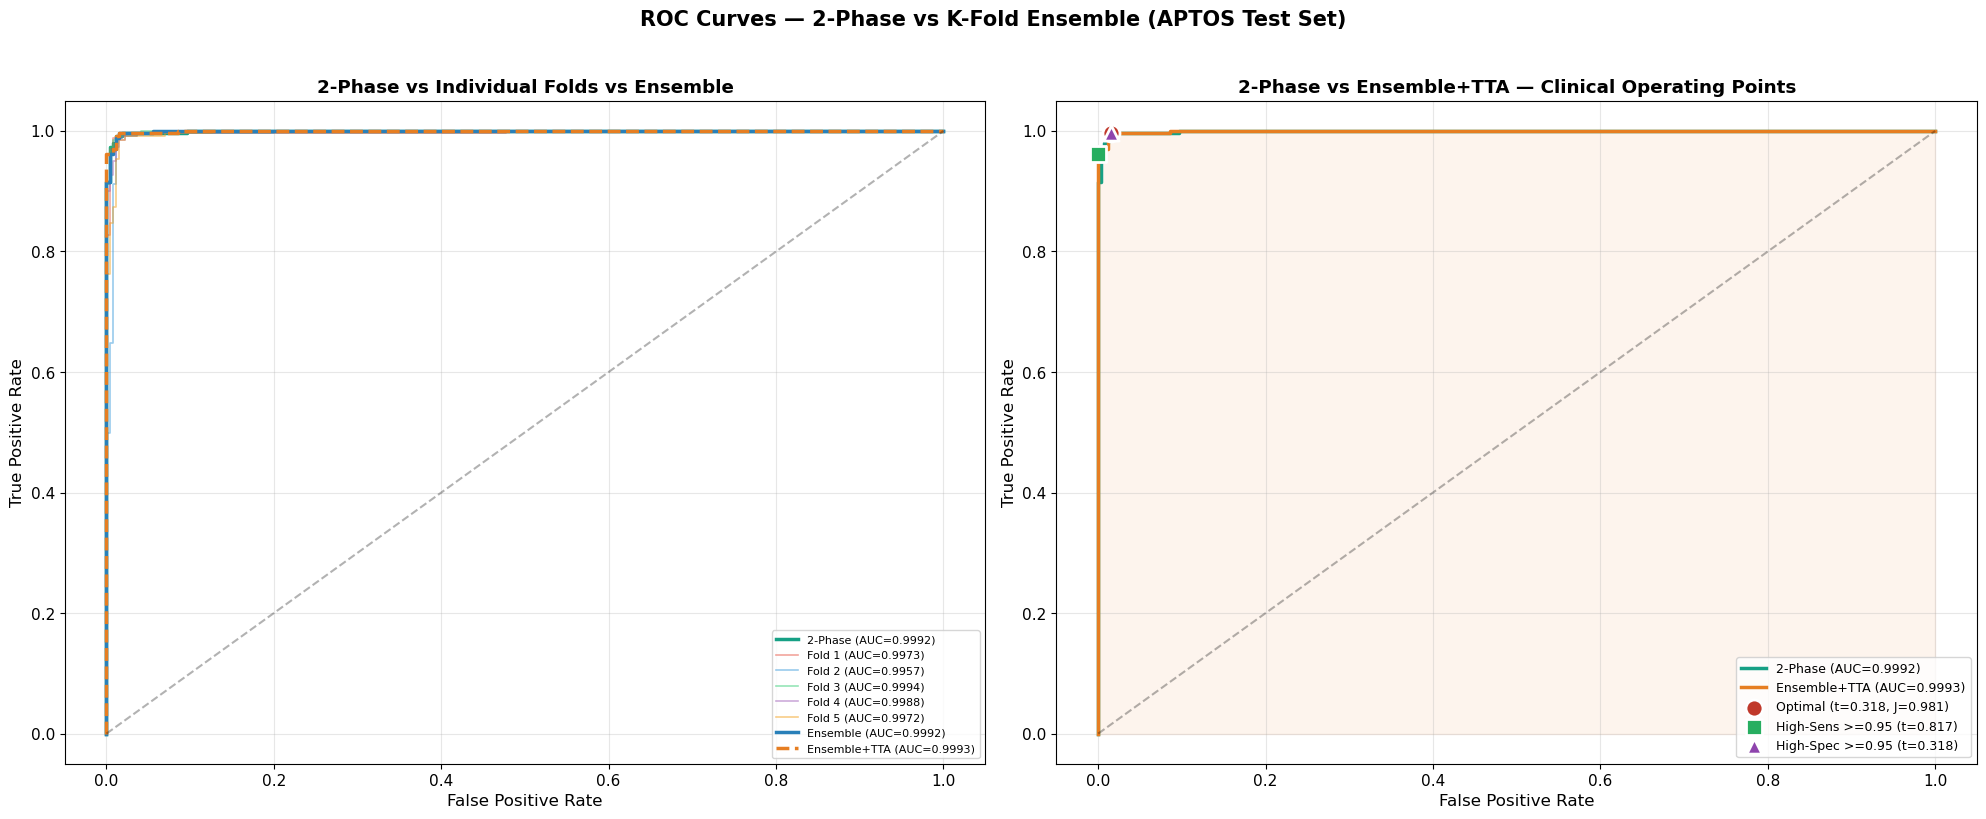

Saved → evaluation/aptos_comprehensive/figures/roc_curves.png


In [14]:
# ============================================================
# 5. ROC Curves — All levels overlaid
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("ROC Curves — 2-Phase vs K-Fold Ensemble (APTOS Test Set)",
             fontsize=15, fontweight="bold", y=1.02)

# ── Panel A: All models ──
ax = axes[0]
fold_colors = [PALETTE["fold1"], PALETTE["fold2"], PALETTE["fold3"],
               PALETTE["fold4"], PALETTE["fold5"]]

# 2-Phase model (prominent)
fpr_tp, tpr_tp, _ = roc_curve(y_true, twophase_probs)
auc_tp = roc_auc_score(y_true, twophase_probs)
ax.plot(fpr_tp, tpr_tp, lw=2.5, color=PALETTE["twophase"],
        label=f"2-Phase (AUC={auc_tp:.4f})")

# Individual folds (light)
for i, (name, probs) in enumerate(fold_probs_noTTA.items()):
    fpr_f, tpr_f, _ = roc_curve(y_true, probs)
    auc_f = roc_auc_score(y_true, probs)
    ax.plot(fpr_f, tpr_f, lw=1.2, alpha=0.5, color=fold_colors[i],
            label=f"{name} (AUC={auc_f:.4f})")

# Ensemble no TTA
fpr_e, tpr_e, _ = roc_curve(y_true, ensemble_noTTA)
auc_e = roc_auc_score(y_true, ensemble_noTTA)
ax.plot(fpr_e, tpr_e, lw=2.5, color=PALETTE["blue"],
        label=f"Ensemble (AUC={auc_e:.4f})")

# Ensemble + TTA
fpr_et, tpr_et, _ = roc_curve(y_true, ensemble_TTA)
auc_et = roc_auc_score(y_true, ensemble_TTA)
ax.plot(fpr_et, tpr_et, lw=2.5, color=PALETTE["orange"], ls="--",
        label=f"Ensemble+TTA (AUC={auc_et:.4f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("2-Phase vs Individual Folds vs Ensemble", fontweight="bold")
ax.legend(fontsize=8, loc="lower right")

# ── Panel B: Best methods zoomed with operating points ──
ax = axes[1]
ax.plot(fpr_tp, tpr_tp, lw=2.5, color=PALETTE["twophase"],
        label=f"2-Phase (AUC={auc_tp:.4f})")
ax.plot(fpr_et, tpr_et, lw=2.5, color=PALETTE["orange"],
        label=f"Ensemble+TTA (AUC={auc_et:.4f})")
ax.fill_between(fpr_et, tpr_et, alpha=0.08, color=PALETTE["orange"])

# Optimal point
ax.scatter(fpr_opt[opt_idx], tpr_opt[opt_idx], color=PALETTE["dr"], s=150,
           zorder=5, edgecolors="white", linewidth=2,
           label=f"Optimal (t={opt_threshold:.3f}, J={J[opt_idx]:.3f})")

# High-sensitivity (>= 0.95)
hi_sens_mask = tpr_opt >= 0.95
hi_sens_thresh = None
if hi_sens_mask.any():
    hi_sens_candidates = np.where(hi_sens_mask)[0]
    best_hi_sens = hi_sens_candidates[np.argmin(fpr_opt[hi_sens_candidates])]
    hi_sens_thresh = thresholds_opt[best_hi_sens]
    ax.scatter(fpr_opt[best_hi_sens], tpr_opt[best_hi_sens], color=PALETTE["no_dr"],
               s=120, marker="s", zorder=5, edgecolors="white", linewidth=2,
               label=f"High-Sens >=0.95 (t={hi_sens_thresh:.3f})")

# High-specificity (>= 0.95)
hi_spec_mask = (1 - fpr_opt) >= 0.95
hi_spec_thresh = None
if hi_spec_mask.any():
    hi_spec_candidates = np.where(hi_spec_mask)[0]
    best_hi_spec = hi_spec_candidates[np.argmax(tpr_opt[hi_spec_candidates])]
    hi_spec_thresh = thresholds_opt[best_hi_spec]
    ax.scatter(fpr_opt[best_hi_spec], tpr_opt[best_hi_spec], color=PALETTE["purple"],
               s=120, marker="^", zorder=5, edgecolors="white", linewidth=2,
               label=f"High-Spec >=0.95 (t={hi_spec_thresh:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("2-Phase vs Ensemble+TTA — Clinical Operating Points", fontweight="bold")
ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig(FIG_DIR / "roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR / 'roc_curves.png'}")

---
## 6. Precision–Recall Curve

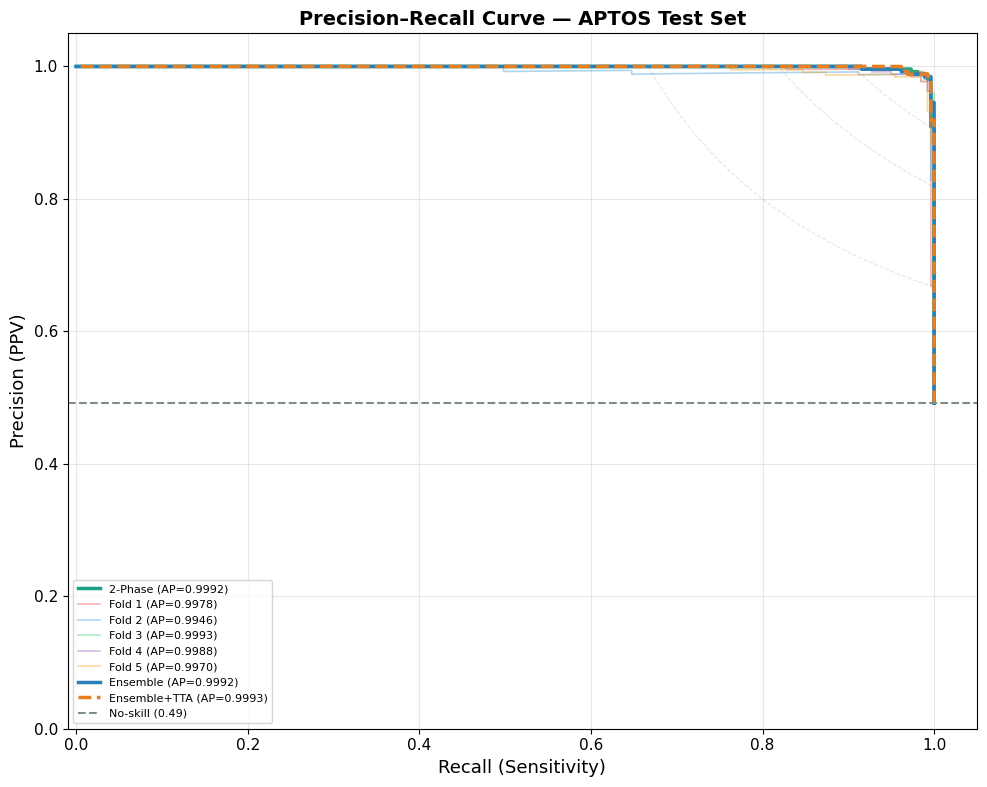

Saved → evaluation/aptos_comprehensive/figures/pr_curve.png


In [16]:
# ============================================================
# 6. Precision-Recall curves
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))

prevalence = y_true.mean()

# 2-Phase model
p_tp, r_tp, _ = precision_recall_curve(y_true, twophase_probs)
ap_tp = auc(r_tp, p_tp)
ax.plot(r_tp, p_tp, lw=2.5, color=PALETTE["twophase"],
        label=f"2-Phase (AP={ap_tp:.4f})")

# Individual folds (light)
for i, (name, probs) in enumerate(fold_probs_noTTA.items()):
    p, r, _ = precision_recall_curve(y_true, probs)
    ap = auc(r, p)
    ax.plot(r, p, lw=1.2, alpha=0.4, color=fold_colors[i],
            label=f"{name} (AP={ap:.4f})")

# Ensemble no TTA
p_e, r_e, _ = precision_recall_curve(y_true, ensemble_noTTA)
ap_e = auc(r_e, p_e)
ax.plot(r_e, p_e, lw=2.5, color=PALETTE["blue"],
        label=f"Ensemble (AP={ap_e:.4f})")

# Ensemble + TTA
p_et, r_et, _ = precision_recall_curve(y_true, ensemble_TTA)
ap_et = auc(r_et, p_et)
ax.plot(r_et, p_et, lw=2.5, color=PALETTE["orange"], ls="--",
        label=f"Ensemble+TTA (AP={ap_et:.4f})")

# Baseline
ax.axhline(y=prevalence, color=PALETTE["gray"], ls="--", lw=1.5,
           label=f"No-skill ({prevalence:.2f})")

# F1 iso-curves
for f1_val in [0.8, 0.9, 0.95]:
    r_ = np.linspace(0.01, 1, 200)
    p_ = f1_val * r_ / (2 * r_ - f1_val)
    valid = (p_ > 0) & (p_ <= 1)
    ax.plot(r_[valid], p_[valid], "--", color="gray", alpha=0.2, lw=0.8)

ax.set_xlabel("Recall (Sensitivity)", fontsize=13)
ax.set_ylabel("Precision (PPV)", fontsize=13)
ax.set_title("Precision–Recall Curve — APTOS Test Set", fontsize=14, fontweight="bold")
ax.legend(fontsize=8, loc="lower left")
ax.set_xlim([-0.01, 1.05])
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig(FIG_DIR / "pr_curve.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR / 'pr_curve.png'}")

---
## 7. Confusion Matrices (Optimal & Clinical Thresholds)

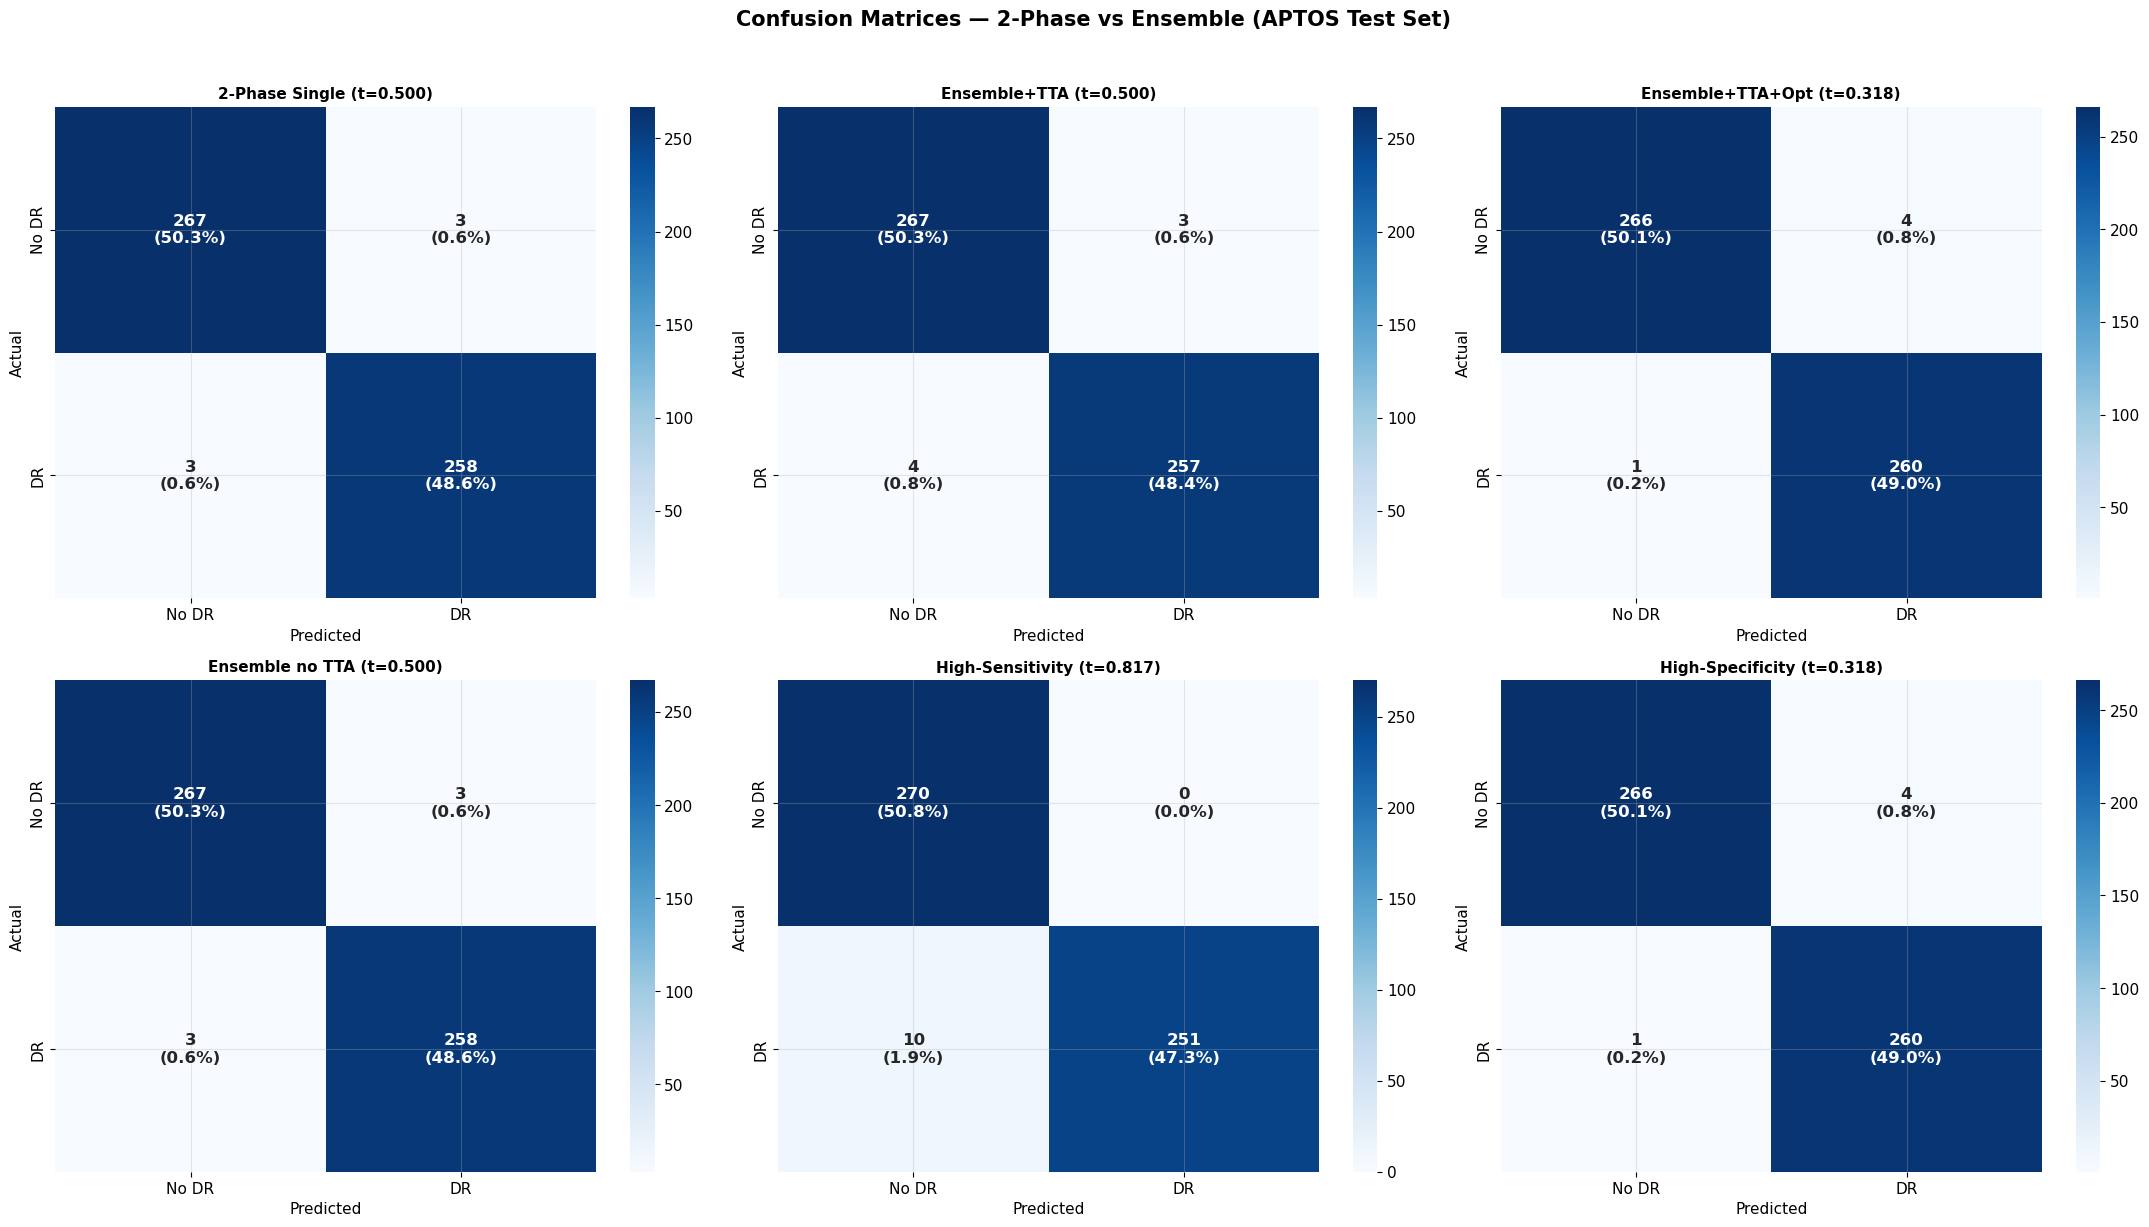

Saved → evaluation/aptos_comprehensive/figures/confusion_matrices.png


In [18]:
# ============================================================
# 7. Confusion matrices at key thresholds
# ============================================================

def plot_cm(y_true, y_pred, ax, title, labels=["No DR", "DR"]):
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm / cm.sum() * 100
    annot = np.array([[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)])
    sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", ax=ax,
                xticklabels=labels, yticklabels=labels,
                annot_kws={"size": 12, "weight": "bold"})
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Actual", fontsize=11)
    ax.set_title(title, fontsize=11, fontweight="bold")


# Row 1: 2-Phase model at t=0.5 | Ensemble+TTA at t=0.5 | Ensemble+TTA at OptThresh
# Row 2: Ensemble(noTTA) at t=0.5 | Ensemble+TTA high-sens | Ensemble+TTA high-spec
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle("Confusion Matrices — 2-Phase vs Ensemble (APTOS Test Set)",
             fontsize=15, fontweight="bold", y=1.02)

# Row 1
plot_cm(y_true, (twophase_probs >= 0.5).astype(int), axes[0, 0],
        "2-Phase Single (t=0.500)")

plot_cm(y_true, (ensemble_TTA >= 0.5).astype(int), axes[0, 1],
        "Ensemble+TTA (t=0.500)")

plot_cm(y_true, (ensemble_TTA >= opt_threshold).astype(int), axes[0, 2],
        f"Ensemble+TTA+Opt (t={opt_threshold:.3f})")

# Row 2
plot_cm(y_true, (ensemble_noTTA >= 0.5).astype(int), axes[1, 0],
        "Ensemble no TTA (t=0.500)")

if hi_sens_thresh is not None:
    plot_cm(y_true, (ensemble_TTA >= hi_sens_thresh).astype(int), axes[1, 1],
            f"High-Sensitivity (t={hi_sens_thresh:.3f})")
else:
    axes[1, 1].axis("off")

if hi_spec_thresh is not None:
    plot_cm(y_true, (ensemble_TTA >= hi_spec_thresh).astype(int), axes[1, 2],
            f"High-Specificity (t={hi_spec_thresh:.3f})")
else:
    axes[1, 2].axis("off")

plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR / 'confusion_matrices.png'}")

---
## 8. Threshold Sensitivity Analysis

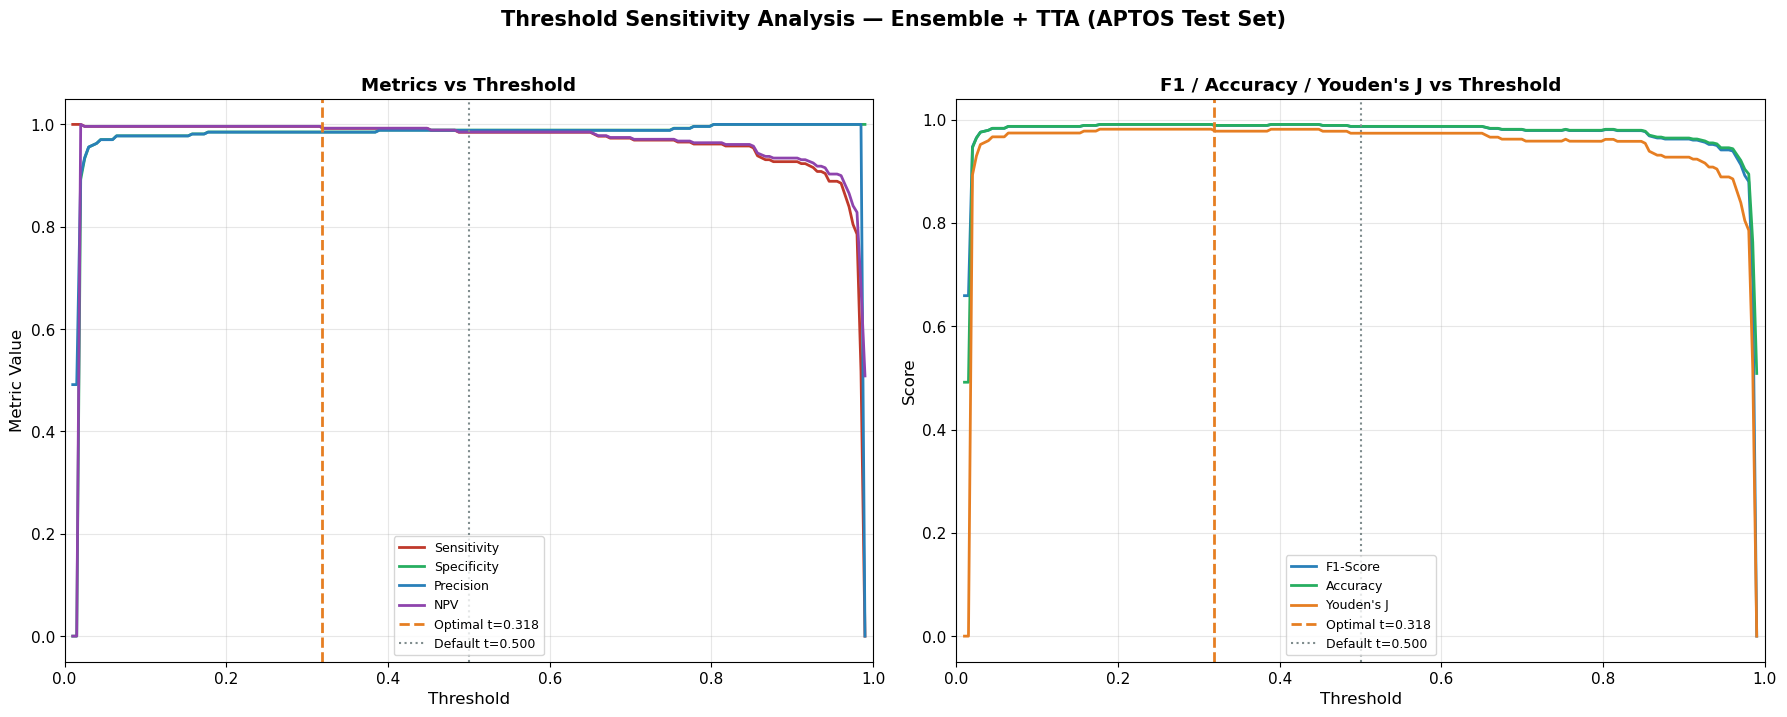

Saved → evaluation/aptos_comprehensive/figures/threshold_analysis.png


In [20]:
# ============================================================
# 8. Threshold sweep (Ensemble+TTA)
# ============================================================
thresholds_sweep = np.linspace(0.01, 0.99, 200)
sweep = {"threshold": [], "sensitivity": [], "specificity": [],
         "precision": [], "npv": [], "f1": [], "accuracy": [], "youden_j": []}

for t in thresholds_sweep:
    yp = (ensemble_TTA >= t).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_true, yp).ravel()
    sens_ = tp_ / (tp_ + fn_) if (tp_ + fn_) > 0 else 0
    spec_ = tn_ / (tn_ + fp_) if (tn_ + fp_) > 0 else 0
    prec_ = tp_ / (tp_ + fp_) if (tp_ + fp_) > 0 else 0
    npv_  = tn_ / (tn_ + fn_) if (tn_ + fn_) > 0 else 0
    f1_   = 2*prec_*sens_ / (prec_+sens_) if (prec_+sens_) > 0 else 0
    acc_  = (tp_ + tn_) / len(y_true)
    sweep["threshold"].append(t)
    sweep["sensitivity"].append(sens_)
    sweep["specificity"].append(spec_)
    sweep["precision"].append(prec_)
    sweep["npv"].append(npv_)
    sweep["f1"].append(f1_)
    sweep["accuracy"].append(acc_)
    sweep["youden_j"].append(sens_ + spec_ - 1)

df_sweep = pd.DataFrame(sweep)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Threshold Sensitivity Analysis — Ensemble + TTA (APTOS Test Set)",
             fontsize=15, fontweight="bold", y=1.02)

# Panel A
ax = axes[0]
ax.plot(df_sweep["threshold"], df_sweep["sensitivity"], lw=2, label="Sensitivity", color=PALETTE["dr"])
ax.plot(df_sweep["threshold"], df_sweep["specificity"], lw=2, label="Specificity", color=PALETTE["no_dr"])
ax.plot(df_sweep["threshold"], df_sweep["precision"], lw=2, label="Precision", color=PALETTE["blue"])
ax.plot(df_sweep["threshold"], df_sweep["npv"], lw=2, label="NPV", color=PALETTE["purple"])
ax.axvline(x=opt_threshold, color=PALETTE["orange"], ls="--", lw=2,
           label=f"Optimal t={opt_threshold:.3f}")
ax.axvline(x=0.5, color=PALETTE["gray"], ls=":", lw=1.5, label="Default t=0.500")
ax.set_xlabel("Threshold", fontsize=12)
ax.set_ylabel("Metric Value", fontsize=12)
ax.set_title("Metrics vs Threshold", fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim([0, 1])

# Panel B
ax = axes[1]
ax.plot(df_sweep["threshold"], df_sweep["f1"], lw=2, label="F1-Score", color=PALETTE["blue"])
ax.plot(df_sweep["threshold"], df_sweep["accuracy"], lw=2, label="Accuracy", color=PALETTE["no_dr"])
ax.plot(df_sweep["threshold"], df_sweep["youden_j"], lw=2, label="Youden's J", color=PALETTE["orange"])
ax.axvline(x=opt_threshold, color=PALETTE["orange"], ls="--", lw=2,
           label=f"Optimal t={opt_threshold:.3f}")
ax.axvline(x=0.5, color=PALETTE["gray"], ls=":", lw=1.5, label="Default t=0.500")
ax.set_xlabel("Threshold", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("F1 / Accuracy / Youden's J vs Threshold", fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim([0, 1])

plt.tight_layout()
plt.savefig(FIG_DIR / "threshold_analysis.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR / 'threshold_analysis.png'}")

---
## 9. Calibration Analysis

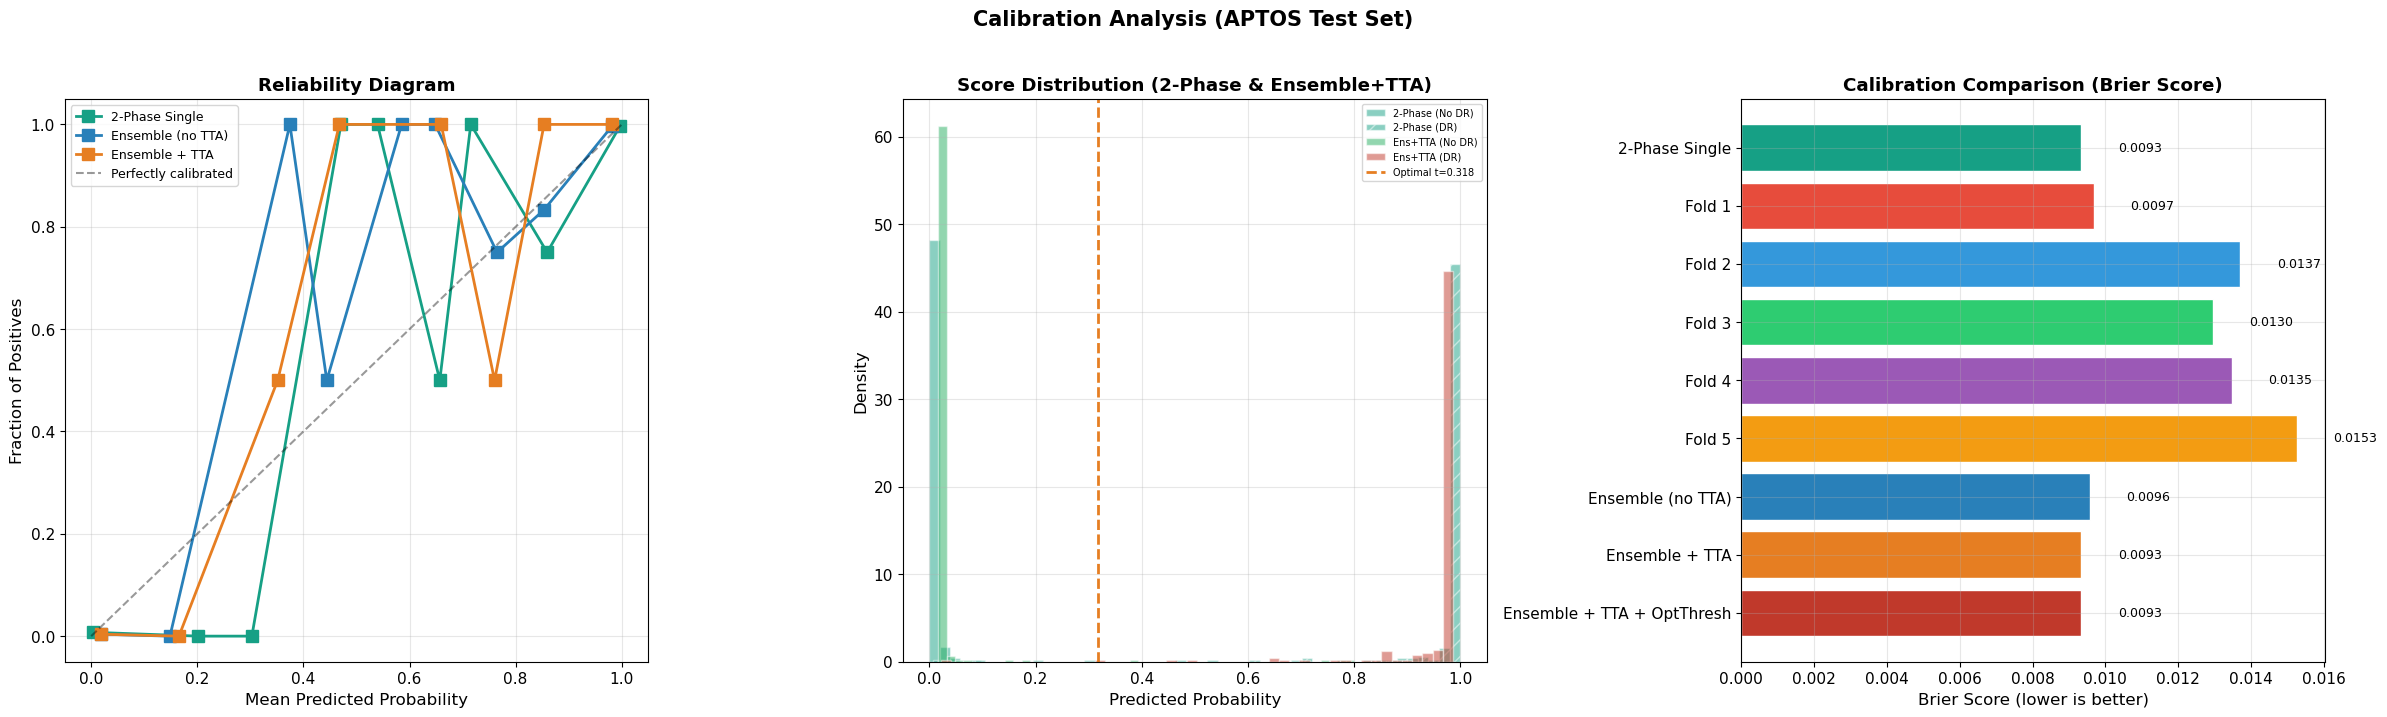

Saved → evaluation/aptos_comprehensive/figures/calibration.png


In [22]:
# ============================================================
# 9. Calibration analysis — 2-Phase vs Ensembles
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle("Calibration Analysis (APTOS Test Set)", fontsize=15, fontweight="bold", y=1.02)

# Panel A: Reliability diagram (2-Phase + both ensembles)
ax = axes[0]
for probs, label, color in [
    (twophase_probs, "2-Phase Single", PALETTE["twophase"]),
    (ensemble_noTTA, "Ensemble (no TTA)", PALETTE["blue"]),
    (ensemble_TTA, "Ensemble + TTA", PALETTE["orange"]),
]:
    prob_true, prob_pred = calibration_curve(y_true, probs, n_bins=10, strategy="uniform")
    ax.plot(prob_pred, prob_true, "s-", color=color, lw=2, markersize=8, label=label)

ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfectly calibrated")
ax.set_xlabel("Mean Predicted Probability", fontsize=12)
ax.set_ylabel("Fraction of Positives", fontsize=12)
ax.set_title("Reliability Diagram", fontweight="bold")
ax.legend(fontsize=9)

# Panel B: Prediction histogram (2-Phase vs Ensemble+TTA)
ax = axes[1]
ax.hist(twophase_probs[y_true == 0], bins=50, alpha=0.5, color=PALETTE["twophase"],
        label="2-Phase (No DR)", density=True, edgecolor="white")
ax.hist(twophase_probs[y_true == 1], bins=50, alpha=0.5, color=PALETTE["twophase"],
        label="2-Phase (DR)", density=True, edgecolor="white", hatch="//")
ax.hist(ensemble_TTA[y_true == 0], bins=50, alpha=0.5, color=PALETTE["no_dr"],
        label="Ens+TTA (No DR)", density=True, edgecolor="white")
ax.hist(ensemble_TTA[y_true == 1], bins=50, alpha=0.5, color=PALETTE["dr"],
        label="Ens+TTA (DR)", density=True, edgecolor="white")
ax.axvline(x=opt_threshold, color=PALETTE["orange"], ls="--", lw=2,
           label=f"Optimal t={opt_threshold:.3f}")
ax.set_xlabel("Predicted Probability", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Score Distribution (2-Phase & Ensemble+TTA)", fontweight="bold")
ax.legend(fontsize=7)

# Panel C: Brier score comparison
ax = axes[2]
brier_data = []
for name, pred_info in all_predictions.items():
    brier_data.append({"Model": name, "Brier Score": brier_score_loss(y_true, pred_info["probs"])})
df_brier = pd.DataFrame(brier_data)
colors = [PALETTE["twophase"]]  # 2-Phase
colors += [PALETTE.get(f"fold{i+1}", PALETTE["gray"]) for i in range(5)]  # folds
colors += [PALETTE["blue"], PALETTE["orange"], PALETTE["dr"]]  # ensembles
bars = ax.barh(df_brier["Model"], df_brier["Brier Score"],
               color=colors[:len(df_brier)], edgecolor="white")
for bar, val in zip(bars, df_brier["Brier Score"]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)
ax.set_xlabel("Brier Score (lower is better)", fontsize=12)
ax.set_title("Calibration Comparison (Brier Score)", fontweight="bold")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(FIG_DIR / "calibration.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR / 'calibration.png'}")

---
## 10. Subgroup Analysis by DR Grade

  SUBGROUP ANALYSIS BY DR GRADE — 2-Phase vs Ensemble+TTA+Opt (APTOS Test Set)

  Grade                N   Bin  2Ph P(DR)  2Ph Acc  2Ph Err  Ens P(DR)  Ens Acc  Ens Err
  --------------------------------------------------------------------------------
  No DR              270     0     0.0134   0.9889        3     0.0299   0.9852        4
  Mild                58     1     0.9323   0.9655        2     0.9198   0.9828        1
  Moderate           144     1     0.9922   0.9931        1     0.9723   1.0000        0
  Severe              22     1     0.9999   1.0000        0     0.9854   1.0000        0
  Proliferative       37     1     0.9972   1.0000        0     0.9619   1.0000        0


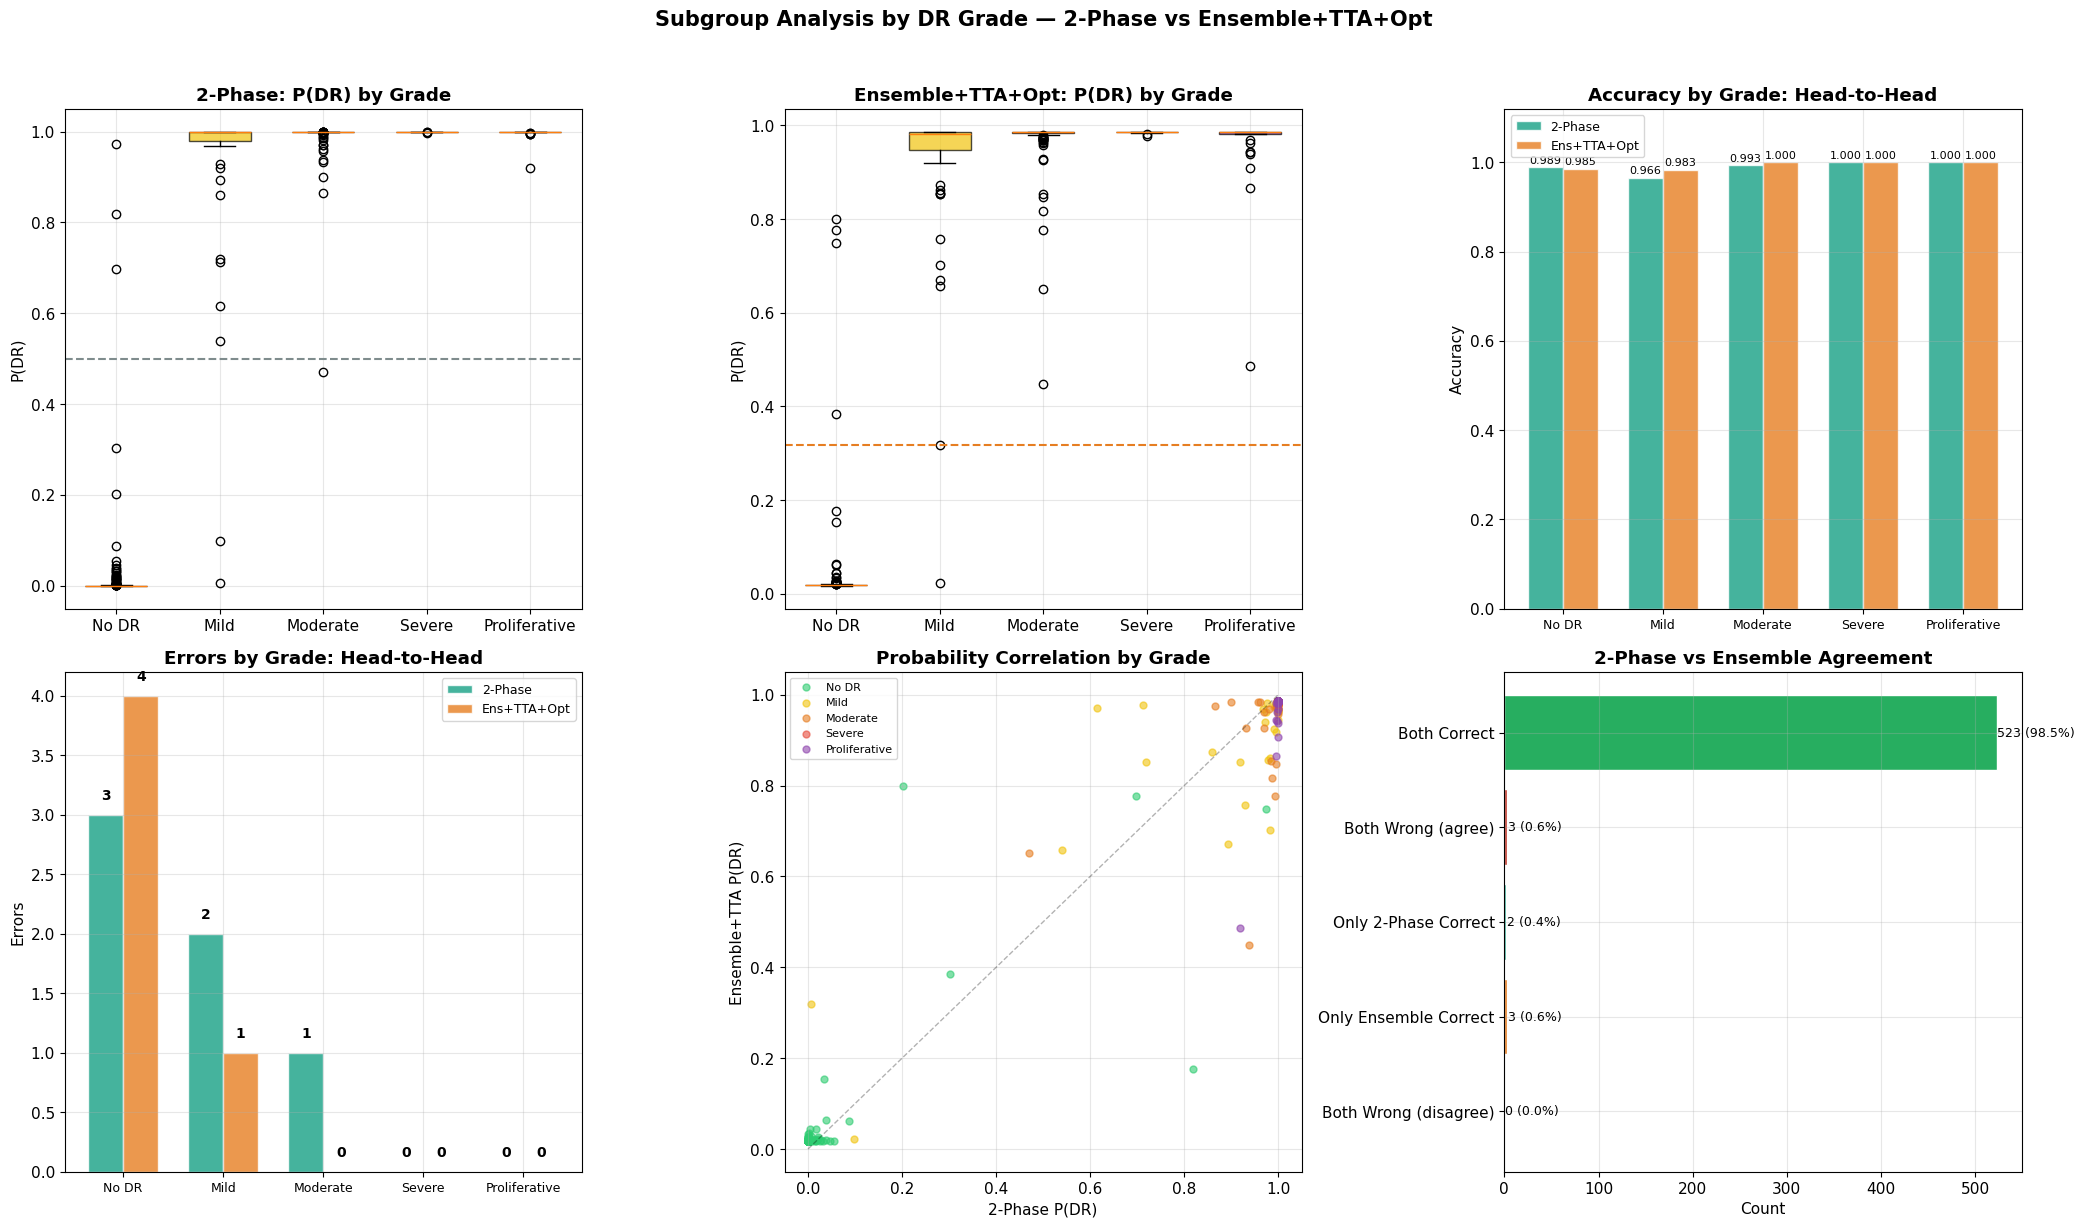

Saved → evaluation/aptos_comprehensive/figures/subgroup_analysis.png


In [24]:
# ============================================================
# 10. Subgroup analysis by DR grade (2-Phase vs Ensemble)
# ============================================================
grade_names = {0: "No DR", 1: "Mild", 2: "Moderate", 3: "Severe", 4: "Proliferative"}
grade_colors = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#8e44ad"]

# Best ensemble level
y_prob_ens = ensemble_TTA
y_pred_ens = (y_prob_ens >= opt_threshold).astype(int)

# 2-Phase predictions
y_pred_tp = (twophase_probs >= 0.5).astype(int)

df_analysis = df_test.copy()
df_analysis["prob_twophase"] = twophase_probs
df_analysis["pred_twophase"] = y_pred_tp
df_analysis["correct_twophase"] = (df_analysis["binary_label"] == y_pred_tp).astype(int)
df_analysis["prob_ensemble"] = y_prob_ens
df_analysis["pred_ensemble"] = y_pred_ens
df_analysis["correct_ensemble"] = (df_analysis["binary_label"] == y_pred_ens).astype(int)

# ── By DR Grade ──
print("=" * 90)
print("  SUBGROUP ANALYSIS BY DR GRADE — 2-Phase vs Ensemble+TTA+Opt (APTOS Test Set)")
print("=" * 90)
print(f"\n  {'Grade':<16s} {'N':>5s} {'Bin':>5s} "
      f"{'2Ph P(DR)':>10s} {'2Ph Acc':>8s} {'2Ph Err':>8s} "
      f"{'Ens P(DR)':>10s} {'Ens Acc':>8s} {'Ens Err':>8s}")
print(f"  {'-'*80}")

subgroup_stats = []
for grade in sorted(df_analysis["dr_grade"].unique()):
    sub = df_analysis[df_analysis["dr_grade"] == grade]
    n = len(sub)
    binary = int(sub["binary_label"].iloc[0])
    # 2-Phase
    tp_mean = sub["prob_twophase"].mean()
    tp_acc = sub["correct_twophase"].mean()
    tp_err = (sub["correct_twophase"] == 0).sum()
    # Ensemble
    ens_mean = sub["prob_ensemble"].mean()
    ens_acc = sub["correct_ensemble"].mean()
    ens_err = (sub["correct_ensemble"] == 0).sum()
    subgroup_stats.append({
        "grade": grade, "name": grade_names[grade], "n": n, "binary": binary,
        "tp_mean_prob": tp_mean, "tp_acc": tp_acc, "tp_errors": tp_err,
        "ens_mean_prob": ens_mean, "ens_acc": ens_acc, "ens_errors": ens_err,
    })
    print(f"  {grade_names[grade]:<16s} {n:>5d} {binary:>5d} "
          f"{tp_mean:>10.4f} {tp_acc:>8.4f} {tp_err:>8d} "
          f"{ens_mean:>10.4f} {ens_acc:>8.4f} {ens_err:>8d}")

# ── Visualization ──
fig, axes = plt.subplots(2, 3, figsize=(21, 12))
fig.suptitle("Subgroup Analysis by DR Grade — 2-Phase vs Ensemble+TTA+Opt",
             fontsize=15, fontweight="bold", y=1.02)

# Row 1: Predicted probabilities box plots
ax = axes[0, 0]
grade_list = sorted(df_analysis["dr_grade"].unique())
data_tp = [df_analysis[df_analysis["dr_grade"] == g]["prob_twophase"].values for g in grade_list]
bp = ax.boxplot(data_tp, labels=[grade_names[g] for g in grade_list],
                patch_artist=True, widths=0.6)
for patch, color in zip(bp["boxes"], grade_colors[:len(data_tp)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(y=0.5, color=PALETTE["gray"], ls="--", lw=1.5)
ax.set_ylabel("P(DR)")
ax.set_title("2-Phase: P(DR) by Grade", fontweight="bold")

ax = axes[0, 1]
data_ens = [df_analysis[df_analysis["dr_grade"] == g]["prob_ensemble"].values for g in grade_list]
bp = ax.boxplot(data_ens, labels=[grade_names[g] for g in grade_list],
                patch_artist=True, widths=0.6)
for patch, color in zip(bp["boxes"], grade_colors[:len(data_ens)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(y=opt_threshold, color=PALETTE["orange"], ls="--", lw=1.5)
ax.set_ylabel("P(DR)")
ax.set_title("Ensemble+TTA+Opt: P(DR) by Grade", fontweight="bold")

# Accuracy comparison side by side
ax = axes[0, 2]
names = [s["name"] for s in subgroup_stats]
x = np.arange(len(names))
width = 0.35
bars1 = ax.bar(x - width/2, [s["tp_acc"] for s in subgroup_stats], width,
               color=PALETTE["twophase"], alpha=0.8, label="2-Phase", edgecolor="white")
bars2 = ax.bar(x + width/2, [s["ens_acc"] for s in subgroup_stats], width,
               color=PALETTE["orange"], alpha=0.8, label="Ens+TTA+Opt", edgecolor="white")
for bar, a in zip(bars1, [s["tp_acc"] for s in subgroup_stats]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{a:.3f}", ha="center", va="bottom", fontsize=8)
for bar, a in zip(bars2, [s["ens_acc"] for s in subgroup_stats]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{a:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy by Grade: Head-to-Head", fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim([0, 1.12])

# Row 2: Error counts
ax = axes[1, 0]
bars1 = ax.bar(x - width/2, [s["tp_errors"] for s in subgroup_stats], width,
               color=PALETTE["twophase"], alpha=0.8, label="2-Phase", edgecolor="white")
bars2 = ax.bar(x + width/2, [s["ens_errors"] for s in subgroup_stats], width,
               color=PALETTE["orange"], alpha=0.8, label="Ens+TTA+Opt", edgecolor="white")
for bar, e in zip(bars1, [s["tp_errors"] for s in subgroup_stats]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(e), ha="center", va="bottom", fontsize=10, fontweight="bold")
for bar, e in zip(bars2, [s["ens_errors"] for s in subgroup_stats]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(e), ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel("Errors")
ax.set_title("Errors by Grade: Head-to-Head", fontweight="bold")
ax.legend(fontsize=9)

# Per-grade AUC (only for grades with both classes — skip)
# Instead: scatter plot of 2-Phase vs Ensemble probabilities
ax = axes[1, 1]
for g in grade_list:
    mask = df_analysis["dr_grade"] == g
    ax.scatter(df_analysis.loc[mask, "prob_twophase"],
              df_analysis.loc[mask, "prob_ensemble"],
              c=grade_colors[g], s=25, alpha=0.6,
              label=grade_names[g])
ax.plot([0, 1], [0, 1], "k--", alpha=0.3, lw=1)
ax.set_xlabel("2-Phase P(DR)")
ax.set_ylabel("Ensemble+TTA P(DR)")
ax.set_title("Probability Correlation by Grade", fontweight="bold")
ax.legend(fontsize=8)

# Agreement/disagreement summary
ax = axes[1, 2]
agree_correct = ((y_pred_tp == y_pred_ens) & (y_pred_ens == y_true)).sum()
agree_wrong   = ((y_pred_tp == y_pred_ens) & (y_pred_ens != y_true)).sum()
tp_only       = ((y_pred_tp == y_true) & (y_pred_ens != y_true)).sum()
ens_only      = ((y_pred_tp != y_true) & (y_pred_ens == y_true)).sum()
both_wrong_diff = ((y_pred_tp != y_true) & (y_pred_ens != y_true) & (y_pred_tp != y_pred_ens)).sum()

agree_data = {
    "Both Correct": agree_correct,
    "Both Wrong (agree)": agree_wrong,
    "Only 2-Phase Correct": tp_only,
    "Only Ensemble Correct": ens_only,
    "Both Wrong (disagree)": both_wrong_diff,
}
labels_ag = list(agree_data.keys())
vals_ag = list(agree_data.values())
colors_ag = ["#27ae60", "#c0392b", PALETTE["twophase"], PALETTE["orange"], "#7f8c8d"]
bars = ax.barh(labels_ag, vals_ag, color=colors_ag, edgecolor="white")
for bar, v in zip(bars, vals_ag):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{v} ({v/len(y_true)*100:.1f}%)", va="center", fontsize=9)
ax.set_xlabel("Count")
ax.set_title("2-Phase vs Ensemble Agreement", fontweight="bold")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(FIG_DIR / "subgroup_analysis.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR / 'subgroup_analysis.png'}")

---
## 11. Error Analysis — Misclassified Cases

  ERROR ANALYSIS — 2-Phase vs Ensemble+TTA+OptThresh (APTOS Test Set)

  Metric                              2-Phase  Ens+TTA+Opt
  -------------------------------------------------------
  Total errors                              6            5
  Error rate                             1.1%         0.9%
  False Positives                           3            4
  False Negatives                           3            1

  False Negatives by DR grade:
    Grade 1 (Mild          ): 2-Phase 2/58  |  Ensemble 1/58
    Grade 2 (Moderate      ): 2-Phase 1/144  |  Ensemble 0/144
    Grade 3 (Severe        ): 2-Phase 0/22  |  Ensemble 0/22
    Grade 4 (Proliferative ): 2-Phase 0/37  |  Ensemble 0/37


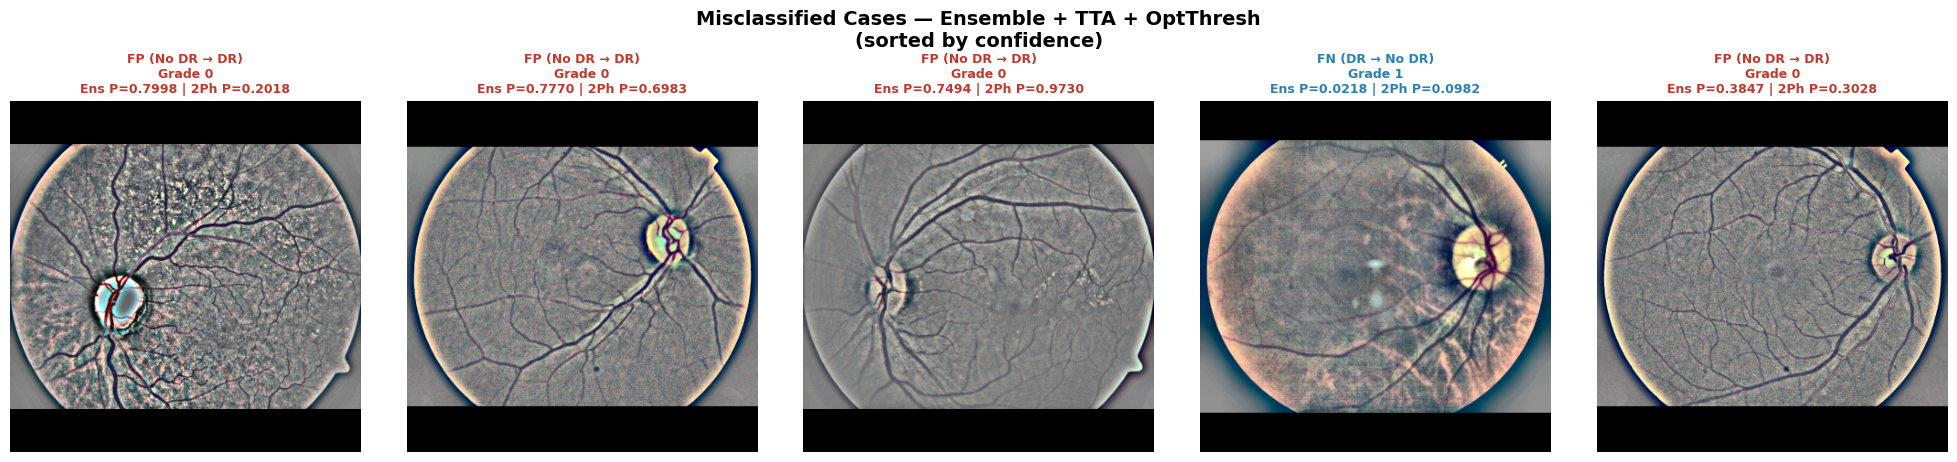

Saved → evaluation/aptos_comprehensive/figures/error_analysis.png


In [26]:
# ============================================================
# 11. Error analysis — comparing 2-Phase vs Ensemble errors
# ============================================================

# Use best ensemble config for error analysis
df_analysis["y_prob"] = y_prob_ens
df_analysis["y_pred"] = y_pred_ens
df_analysis["correct"] = df_analysis["correct_ensemble"]

df_errors_ens = df_analysis[df_analysis["correct_ensemble"] == 0].copy()
df_errors_tp  = df_analysis[df_analysis["correct_twophase"] == 0].copy()

# Ensemble errors
fp_ens = (df_errors_ens["binary_label"] == 0).sum()
fn_ens = (df_errors_ens["binary_label"] == 1).sum()

# 2-Phase errors
fp_tp = (df_errors_tp["binary_label"] == 0).sum()
fn_tp = (df_errors_tp["binary_label"] == 1).sum()

print("=" * 75)
print("  ERROR ANALYSIS — 2-Phase vs Ensemble+TTA+OptThresh (APTOS Test Set)")
print("=" * 75)
print(f"\n  {'Metric':<30s} {'2-Phase':>12s} {'Ens+TTA+Opt':>12s}")
print(f"  {'-'*55}")
print(f"  {'Total errors':<30s} {len(df_errors_tp):>12d} {len(df_errors_ens):>12d}")
print(f"  {'Error rate':<30s} {len(df_errors_tp)/len(df_analysis)*100:>11.1f}% {len(df_errors_ens)/len(df_analysis)*100:>11.1f}%")
print(f"  {'False Positives':<30s} {fp_tp:>12d} {fp_ens:>12d}")
print(f"  {'False Negatives':<30s} {fn_tp:>12d} {fn_ens:>12d}")

# FN by grade for both
print(f"\n  False Negatives by DR grade:")
for grade in sorted(df_analysis["dr_grade"].unique()):
    if grade == 0:
        continue
    total_g = len(df_analysis[df_analysis["dr_grade"] == grade])
    fn_tp_g = len(df_errors_tp[(df_errors_tp["binary_label"] == 1) & (df_errors_tp["dr_grade"] == grade)])
    fn_ens_g = len(df_errors_ens[(df_errors_ens["binary_label"] == 1) & (df_errors_ens["dr_grade"] == grade)])
    print(f"    Grade {grade} ({grade_names[grade]:<14s}): 2-Phase {fn_tp_g}/{total_g}  |  Ensemble {fn_ens_g}/{total_g}")

# ── Visualize misclassified samples (Ensemble errors) ──
df_errors_vis = df_errors_ens.copy()
df_errors_vis["error_type"] = df_errors_vis.apply(
    lambda r: "FP (No DR → DR)" if r["binary_label"] == 0 else "FN (DR → No DR)", axis=1
)
df_errors_vis["confidence"] = np.abs(df_errors_vis["prob_ensemble"] - opt_threshold)

n_show = min(len(df_errors_vis), 10)
if n_show > 0:
    df_errors_sorted = df_errors_vis.sort_values("confidence", ascending=False)
    n_cols = min(n_show, 5)
    n_rows = (n_show + n_cols - 1) // n_cols

    fig, axes_err = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4.5 * n_rows))
    fig.suptitle("Misclassified Cases — Ensemble + TTA + OptThresh\n(sorted by confidence)",
                 fontsize=14, fontweight="bold", y=1.02)
    if n_rows == 1 and n_cols == 1:
        axes_err = np.array([[axes_err]])
    elif n_rows == 1:
        axes_err = axes_err.reshape(1, -1)

    for i in range(n_rows * n_cols):
        r, c = i // n_cols, i % n_cols
        ax = axes_err[r, c]
        if i < n_show:
            row = df_errors_sorted.iloc[i]
            img = cv2.imread(str(ROOT / row["preprocessed_path"]))
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img)
            color = PALETTE["dr"] if row["error_type"].startswith("FP") else PALETTE["blue"]
            ax.set_title(f"{row['error_type']}\nGrade {int(row['dr_grade'])}\n"
                         f"Ens P={row['prob_ensemble']:.4f} | 2Ph P={row['prob_twophase']:.4f}",
                         fontsize=9, color=color, fontweight="bold")
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(FIG_DIR / "error_analysis.png", dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved → {FIG_DIR / 'error_analysis.png'}")
else:
    print("\n  ✓ No misclassified cases! Perfect classification on test set.")

---
## 12. Summary Dashboard & Export

ValueError: Found input variables with inconsistent numbers of samples: [487, 488]

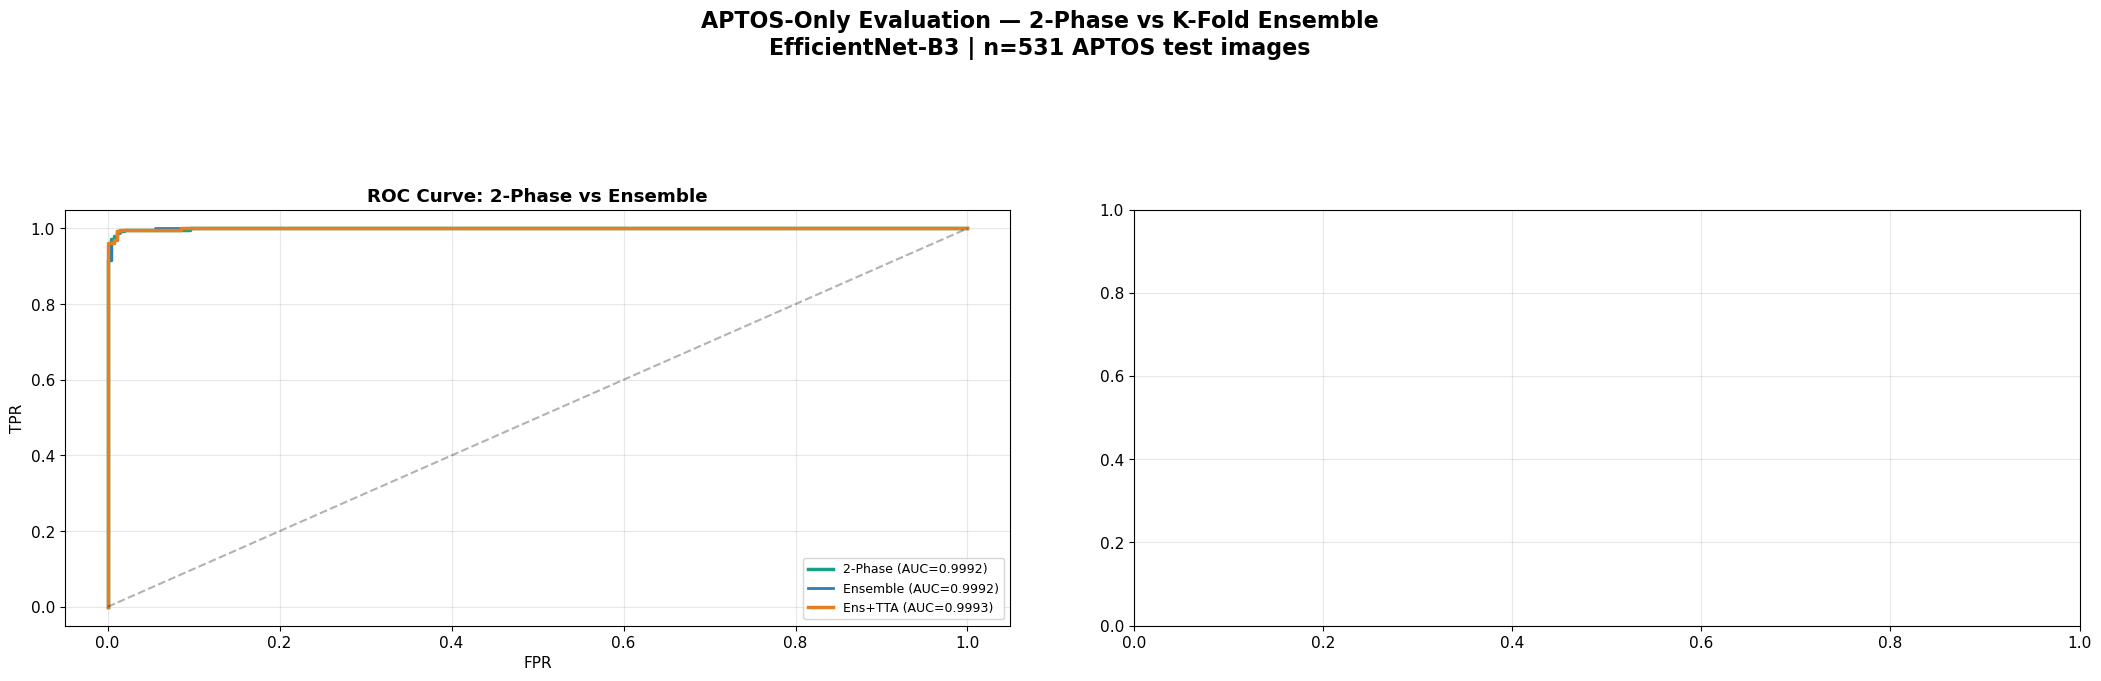

In [33]:
# ============================================================
# 12a. Summary dashboard
# ============================================================
fig = plt.figure(figsize=(26, 20))
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.35, wspace=0.3)
fig.suptitle("APTOS-Only Evaluation — 2-Phase vs K-Fold Ensemble\n"
             f"EfficientNet-B3 | n={len(y_true)} APTOS test images",
             fontsize=16, fontweight="bold", y=0.98)

prevalence = y_true.mean()

# (0,0-1) ROC — head-to-head
ax = fig.add_subplot(gs[0, 0:2])
for probs, label, color, lw in [
    (twophase_probs, f"2-Phase (AUC={roc_auc_score(y_true, twophase_probs):.4f})", PALETTE["twophase"], 2.5),
    (ensemble_noTTA, f"Ensemble (AUC={roc_auc_score(y_true, ensemble_noTTA):.4f})", PALETTE["blue"], 2),
    (ensemble_TTA, f"Ens+TTA (AUC={roc_auc_score(y_true, ensemble_TTA):.4f})", PALETTE["orange"], 2.5),
]:
    f_, t_, _ = roc_curve(y_true, probs)
    ax.plot(f_, t_, lw=lw, color=color, label=label)
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC Curve: 2-Phase vs Ensemble", fontweight="bold")
ax.legend(fontsize=9)

# (0,2-3) PR curve
ax = fig.add_subplot(gs[0, 2:4])
for probs, label, color in [
    (twophase_probs, f"2-Phase (AP={auc(*precision_recall_curve(y_true, twophase_probs)[::-1][:2]):.4f})", PALETTE["twophase"]),
    (ensemble_TTA, f"Ens+TTA (AP={auc(*precision_recall_curve(y_true, ensemble_TTA)[::-1][:2]):.4f})", PALETTE["orange"]),
]:
    p_, r_, _ = precision_recall_curve(y_true, probs)
    ax.plot(r_, p_, lw=2.5, color=color, label=label)
ax.axhline(y=prevalence, color="gray", ls="--", alpha=0.5)
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("PR Curve: 2-Phase vs Ensemble+TTA", fontweight="bold")
ax.legend(fontsize=9)

# (1,0) 2-Phase confusion matrix
ax = fig.add_subplot(gs[1, 0])
cm_tp = confusion_matrix(y_true, y_pred_tp)
cm_tp_pct = cm_tp / cm_tp.sum() * 100
annot_tp = np.array([[f"{cm_tp[i,j]}\n({cm_tp_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)])
sns.heatmap(cm_tp, annot=annot_tp, fmt="", cmap="Greens", ax=ax,
            xticklabels=["No DR", "DR"], yticklabels=["No DR", "DR"],
            annot_kws={"size": 10})
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("CM — 2-Phase (t=0.500)", fontweight="bold")

# (1,1) Ensemble+TTA+OptThresh confusion matrix
ax = fig.add_subplot(gs[1, 1])
cm_ens = confusion_matrix(y_true, y_pred_ens)
cm_ens_pct = cm_ens / cm_ens.sum() * 100
annot_ens = np.array([[f"{cm_ens[i,j]}\n({cm_ens_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)])
sns.heatmap(cm_ens, annot=annot_ens, fmt="", cmap="Blues", ax=ax,
            xticklabels=["No DR", "DR"], yticklabels=["No DR", "DR"],
            annot_kws={"size": 10})
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"CM — Ens+TTA+Opt (t={opt_threshold:.3f})", fontweight="bold")

# (1,2) Calibration
ax = fig.add_subplot(gs[1, 2])
for probs, label, color in [
    (twophase_probs, "2-Phase", PALETTE["twophase"]),
    (ensemble_TTA, "Ens+TTA", PALETTE["orange"]),
]:
    pt, pp = calibration_curve(y_true, probs, n_bins=10)
    ax.plot(pp, pt, "s-", color=color, lw=2, label=label)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_title("Calibration", fontweight="bold")
ax.legend(fontsize=9)

# (1,3) Head-to-head metrics table
ax = fig.add_subplot(gs[1, 3])
ax.axis("off")
m_tp = [m for m in all_metrics if m["Model"] == "2-Phase Single"][0]
m_ens = [m for m in all_metrics if m["Model"] == "Ensemble + TTA + OptThresh"][0]
table_data = []
for metric in ["AUC-ROC", "AUC-PR", "Accuracy", "Sensitivity", "Specificity",
               "Precision", "F1-Score", "Cohen Kappa", "MCC", "Brier Score"]:
    v1 = m_tp.get(metric, 0)
    v2 = m_ens.get(metric, 0)
    diff = v2 - v1
    sign = "+" if diff >= 0 else ""
    table_data.append([metric, f"{v1:.4f}", f"{v2:.4f}", f"{sign}{diff:.4f}"])
table = ax.table(cellText=table_data,
                 colLabels=["Metric", "2-Phase", "Ens+TTA+Opt", "Δ"],
                 loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.5)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(fontweight="bold")
        cell.set_facecolor("#d5e8d4")
    elif col == 3 and row > 0:
        # Color the delta column
        val = table_data[row-1][3]
        if val.startswith("+"):
            cell.set_facecolor("#d4edda")
        elif val.startswith("-"):
            cell.set_facecolor("#f8d7da")
ax.set_title("Head-to-Head Comparison", fontweight="bold", pad=15)

# (2,0-1) Threshold analysis
ax = fig.add_subplot(gs[2, 0:2])
ax.plot(df_sweep["threshold"], df_sweep["sensitivity"], lw=2, color=PALETTE["dr"], label="Sensitivity")
ax.plot(df_sweep["threshold"], df_sweep["specificity"], lw=2, color=PALETTE["no_dr"], label="Specificity")
ax.plot(df_sweep["threshold"], df_sweep["f1"], lw=2, color=PALETTE["blue"], label="F1")
ax.axvline(x=opt_threshold, color=PALETTE["orange"], ls="--", lw=2)
ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.set_title("Threshold Sensitivity (Ensemble+TTA)", fontweight="bold")
ax.legend(fontsize=8)

# (2,2-3) AUC-ROC comparison bar chart
ax = fig.add_subplot(gs[2, 2:4])
comp_names = df_comp["Model"].tolist()
comp_aucs = df_comp["AUC-ROC"].tolist()
y_pos = np.arange(len(comp_names))
bar_colors = ([PALETTE["twophase"]]
              + [PALETTE[f"fold{i+1}"] for i in range(5)]
              + [PALETTE["blue"], PALETTE["orange"], PALETTE["dr"]])
bars = ax.barh(y_pos, comp_aucs, color=bar_colors[:len(comp_names)], edgecolor="white")
for bar, val in zip(bars, comp_aucs):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)
ax.set_yticks(y_pos)
ax.set_yticklabels(comp_names, fontsize=9)
ax.set_xlabel("AUC-ROC")
ax.set_title("AUC-ROC Comparison — All Levels", fontweight="bold")
ax.invert_yaxis()

plt.savefig(FIG_DIR / "dashboard.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR / 'dashboard.png'}")

In [ ]:
# ============================================================
# 12b. Export all results for paper
# ============================================================

# 1. Full comparison table
df_comp.to_csv(EVAL_DIR / "comparison_table.csv", index=False)

# 2. Comprehensive JSON
export = {
    "dataset": "APTOS 2019 (test split only)",
    "task": "binary_classification",
    "model": CONFIG["model_name"],
    "image_size": CONFIG["image_size"],
    "n_folds": CONFIG["n_folds"],
    "tta_times": CONFIG["tta_times"],
    "test_size": int(len(y_true)),
    "prevalence": float(prevalence),
    "optimal_threshold": float(opt_threshold),
    "youdens_j": float(J[opt_idx]),
    "evaluation_levels": {},
    "subgroup_analysis": {"by_grade": subgroup_stats},
    "agreement_analysis": {k: int(v) for k, v in agree_data.items()},
    "bootstrap_n": CONFIG["bootstrap_n"],
}

for m in all_metrics:
    level = m["Model"]
    level_data = {k: float(v) if isinstance(v, (np.floating, float)) else v
                  for k, v in m.items() if k not in ["Model"]}
    # Convert CI tuples
    for key in list(level_data.keys()):
        if isinstance(level_data[key], tuple):
            level_data[key] = {"lower": float(level_data[key][0]), "upper": float(level_data[key][1])}
    export["evaluation_levels"][level] = level_data

with open(EVAL_DIR / "comprehensive_eval.json", "w") as f:
    json.dump(export, f, indent=2, default=str)

# 3. Predictions CSV
df_predictions = df_analysis[["image_id", "preprocessed_path",
                              "dr_grade", "binary_label",
                              "prob_twophase", "pred_twophase", "correct_twophase",
                              "prob_ensemble", "pred_ensemble", "correct_ensemble"]].copy()
# Add all fold probabilities
for name, probs in fold_probs_TTA.items():
    df_predictions[f"prob_{name.lower().replace(' ', '_')}_tta"] = probs
df_predictions["prob_ensemble_noTTA"] = ensemble_noTTA
df_predictions["prob_ensemble_TTA"] = ensemble_TTA
df_predictions.to_csv(EVAL_DIR / "test_predictions_full.csv", index=False)

# 4. Threshold sweep
df_sweep.to_csv(EVAL_DIR / "threshold_sweep.csv", index=False)

print("Exported for paper:")
for f in sorted(EVAL_DIR.glob("*")):
    if f.is_file():
        size = f.stat().st_size / 1024
        print(f"  ✓ {f.name} ({size:.1f} KB)")
for f in sorted(FIG_DIR.glob("*.png")):
    size = f.stat().st_size / 1024
    print(f"  ✓ figures/{f.name} ({size:.1f} KB)")

In [ ]:
# ============================================================
# 13. Final Summary
# ============================================================
print("=" * 90)
print("  APTOS-ONLY EVALUATION — 2-Phase vs K-Fold Ensemble — COMPLETE")
print("=" * 90)

print(f"\n  Model            : {CONFIG['model_name']}")
print(f"  Test set         : APTOS 2019 only ({len(y_true)} images)")
print(f"  K-Fold           : {CONFIG['n_folds']}-fold (trained on multi-source data)")
print(f"  2-Phase          : Single model (trained on APTOS only)")
print(f"  TTA              : {CONFIG['tta_times']}x augmentation")
print(f"  Optimal threshold: {opt_threshold:.4f}")

# Get metrics for each level
print(f"\n  {'Level':<35s} {'AUC':>8s} {'Acc':>8s} {'F1':>8s} {'Sens':>8s} {'Spec':>8s} {'Kappa':>8s}")
print(f"  {'-'*85}")
for m in all_metrics:
    print(f"  {m['Model']:<35s} {m['AUC-ROC']:>8.4f} {m['Accuracy']:>8.4f} "
          f"{m['F1-Score']:>8.4f} {m['Sensitivity']:>8.4f} {m['Specificity']:>8.4f} "
          f"{m['Cohen Kappa']:>8.4f}")

# Head-to-head
m_tp = [m for m in all_metrics if m["Model"] == "2-Phase Single"][0]
m_best = [m for m in all_metrics if m["Model"] == "Ensemble + TTA + OptThresh"][0]
print(f"\n  ┌─────────────────────────────────────────────────┐")
print(f"  │  HEAD-TO-HEAD: 2-Phase vs Ensemble+TTA+Opt      │")
print(f"  ├─────────────────────────────────────────────────┤")
print(f"  │  AUC-ROC  : {m_tp['AUC-ROC']:.4f} vs {m_best['AUC-ROC']:.4f}  (Δ = {m_best['AUC-ROC']-m_tp['AUC-ROC']:+.4f}) │")
print(f"  │  Accuracy : {m_tp['Accuracy']:.4f} vs {m_best['Accuracy']:.4f}  (Δ = {m_best['Accuracy']-m_tp['Accuracy']:+.4f}) │")
print(f"  │  F1-Score : {m_tp['F1-Score']:.4f} vs {m_best['F1-Score']:.4f}  (Δ = {m_best['F1-Score']-m_tp['F1-Score']:+.4f}) │")
print(f"  │  Kappa    : {m_tp['Cohen Kappa']:.4f} vs {m_best['Cohen Kappa']:.4f}  (Δ = {m_best['Cohen Kappa']-m_tp['Cohen Kappa']:+.4f}) │")
print(f"  │  Errors   : {m_tp['FP']+m_tp['FN']:>5d} vs {m_best['FP']+m_best['FN']:>5d}         (Δ = {(m_best['FP']+m_best['FN'])-(m_tp['FP']+m_tp['FN']):+d})     │")
print(f"  └─────────────────────────────────────────────────┘")

# Agreement
print(f"\n  Model Agreement:")
for k, v in agree_data.items():
    print(f"    {k:<30s}: {v:>4d} ({v/len(y_true)*100:.1f}%)")

print(f"\n  Output directory: {EVAL_DIR}")

# Cleanup
del fold_models, twophase_model
gc.collect()
if DEVICE.type == "mps":
    torch.mps.empty_cache()
print("\n  Memory cleaned up ✓")

---
## Evaluation Complete!

**Output files for paper:**

| File | Description |
|------|-------------|
| `comparison_table.csv` | All metrics for all 9 evaluation levels |
| `comprehensive_eval.json` | Complete results with CIs & subgroups |
| `test_predictions_full.csv` | Per-image predictions (both models) |
| `threshold_sweep.csv` | Threshold sensitivity data |
| `figures/roc_curves.png` | ROC curves (2-Phase + Folds + Ensemble) |
| `figures/pr_curve.png` | PR curves |
| `figures/confusion_matrices.png` | 6 confusion matrices |
| `figures/threshold_analysis.png` | Threshold sweep plots |
| `figures/calibration.png` | Reliability + Brier score |
| `figures/subgroup_analysis.png` | DR grade subgroup comparison |
| `figures/error_analysis.png` | Misclassified image gallery |
| `figures/dashboard.png` | Comprehensive summary dashboard |